<a href="https://colab.research.google.com/github/YadurajSiddarth/prg4206-arrhythmia-project/blob/main/PRG4206_Arrhythmia_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
from pathlib import Path

DATA_DIR = Path(
    "/content/drive/MyDrive/PRG4206_Arrhythmia_Project/data"
)

ZIP_PATH = DATA_DIR / "ptb-xl.zip"

if ZIP_PATH.exists():
    ZIP_PATH.unlink()
    print("Removed incomplete ZIP.")
else:
    print("No existing ZIP found.")

print("Data folder:", DATA_DIR)

No existing ZIP found.
Data folder: /content/drive/MyDrive/PRG4206_Arrhythmia_Project/data


In [14]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path(
    "/content/drive/MyDrive/PRG4206_Arrhythmia_Project/data"
)

# Load the two CSV files
df = pd.read_csv("/content/ptbxl_database.csv")
scp = pd.read_csv("/content/scp_statements.csv")

# Basic information
print("PTB-XL metadata shape:", df.shape)
print("Diagnostic statements shape:", scp.shape)

print("\nFirst 5 ECG records:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nDiagnostic statement columns:")
print(scp.columns.tolist())

PTB-XL metadata shape: (21837, 28)
Diagnostic statements shape: (71, 13)

First 5 ECG records:


,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr



Column names:
['ecg_id', 'patient_id', 'age', 'sex', 'height', 'weight', 'nurse', 'site', 'device', 'recording_date', 'report', 'scp_codes', 'heart_axis', 'infarction_stadium1', 'infarction_stadium2', 'validated_by', 'second_opinion', 'initial_autogenerated_report', 'validated_by_human', 'baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems', 'extra_beats', 'pacemaker', 'strat_fold', 'filename_lr', 'filename_hr']

Diagnostic statement columns:
['Unnamed: 0', 'description', 'diagnostic', 'form', 'rhythm', 'diagnostic_class', 'diagnostic_subclass', 'Statement Category', 'SCP-ECG Statement Description', 'AHA code', 'aECG REFID', 'CDISC Code', 'DICOM Code']


In [15]:
print("Missing values in important columns:")
display(
    df[["patient_id", "strat_fold", "scp_codes"]]
    .isnull()
    .sum()
)

print("\nExample diagnostic labels:")
display(df[["ecg_id", "patient_id", "scp_codes"]].head(10))

print("\nAvailable diagnostic superclasses:")
display(scp.head(10))

Missing values in important columns:


,0
patient_id,0
strat_fold,0
scp_codes,0



Example diagnostic labels:


,ecg_id,patient_id,scp_codes
0,1,15709.0,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}"
1,2,13243.0,"{'NORM': 80.0, 'SBRAD': 0.0}"
2,3,20372.0,"{'NORM': 100.0, 'SR': 0.0}"
3,4,17014.0,"{'NORM': 100.0, 'SR': 0.0}"
4,5,17448.0,"{'NORM': 100.0, 'SR': 0.0}"
5,6,19005.0,"{'NORM': 100.0, 'SR': 0.0}"
6,7,16193.0,"{'NORM': 100.0, 'SR': 0.0}"
7,8,11275.0,"{'IMI': 35.0, 'ABQRS': 0.0, 'SR': 0.0}"
8,9,18792.0,"{'NORM': 100.0, 'SR': 0.0}"
9,10,9456.0,"{'NORM': 100.0, 'SR': 0.0}"



Available diagnostic superclasses:


,Unnamed: 0,description,diagnostic,form,rhythm,diagnostic_class,diagnostic_subclass,Statement Category,SCP-ECG Statement Description,AHA code,aECG REFID,CDISC Code,DICOM Code
0,NDT,non-diagnostic T abnormalities,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,non-diagnostic T abnormalities,NaN,NaN,NaN,NaN
1,NST_,non-specific ST changes,1.0,1.0,NaN,STTC,NST_,Basic roots for coding ST-T changes and abnorm...,non-specific ST changes,145.0,MDC_ECG_RHY_STHILOST,NaN,NaN
2,DIG,digitalis-effect,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,suggests digitalis-effect,205.0,NaN,NaN,NaN
3,LNGQT,long QT-interval,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,long QT-interval,148.0,NaN,NaN,NaN
4,NORM,normal ECG,1.0,NaN,NaN,NORM,NORM,Normal/abnormal,normal ECG,1.0,NaN,NaN,F-000B7
5,IMI,inferior myocardial infarction,1.0,NaN,NaN,MI,IMI,Myocardial Infarction,inferior myocardial infarction,161.0,NaN,NaN,NaN
6,ASMI,anteroseptal myocardial infarction,1.0,NaN,NaN,MI,AMI,Myocardial Infarction,anteroseptal myocardial infarction,165.0,NaN,NaN,NaN
7,LVH,left ventricular hypertrophy,1.0,NaN,NaN,HYP,LVH,Ventricular Hypertrophy,left ventricular hypertrophy,142.0,NaN,C71076,NaN
8,LAFB,left anterior fascicular block,1.0,NaN,NaN,CD,LAFB/LPFB,Intraventricular and intra-atrial Conduction d...,left anterior fascicular block,101.0,MDC_ECG_BEAT_BLK_ANT_L_HEMI,C62267,D3-33140
9,ISC_,non-specific ischemic,1.0,NaN,NaN,STTC,ISC_,Basic roots for coding ST-T changes and abnorm...,ischemic ST-T changes,226.0,NaN,NaN,NaN


In [17]:
import ast
import pandas as pd
from pathlib import Path

DATA_DIR = Path(
    "/content/drive/MyDrive/PRG4206_Arrhythmia_Project/data"
)

df = pd.read_csv("/content/ptbxl_database.csv")
scp = pd.read_csv("/content/ptbxl_database.csv")

# Inspect the available mapping columns
print("SCP statement columns:")
print(scp.columns.tolist())

display(scp.head())

SCP statement columns:
['ecg_id', 'patient_id', 'age', 'sex', 'height', 'weight', 'nurse', 'site', 'device', 'recording_date', 'report', 'scp_codes', 'heart_axis', 'infarction_stadium1', 'infarction_stadium2', 'validated_by', 'second_opinion', 'initial_autogenerated_report', 'validated_by_human', 'baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems', 'extra_beats', 'pacemaker', 'strat_fold', 'filename_lr', 'filename_hr']


,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


In [18]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("/content")

df = pd.read_csv(DATA_DIR / "ptbxl_database.csv")
scp = pd.read_csv(DATA_DIR / "scp_statements.csv")

print("Dataset statistics")
print("-" * 40)
print("ECG metadata shape:", df.shape)
print("Diagnostic statements shape:", scp.shape)

print("\nMetadata columns:")
print(df.columns.tolist())

print("\nDiagnostic statement columns:")
print(scp.columns.tolist())

print("\nFirst 5 ECG records:")
display(df.head())

print("\nFirst 10 diagnostic statements:")
display(scp.head(10))

Dataset statistics
----------------------------------------
ECG metadata shape: (21837, 28)
Diagnostic statements shape: (71, 13)

Metadata columns:
['ecg_id', 'patient_id', 'age', 'sex', 'height', 'weight', 'nurse', 'site', 'device', 'recording_date', 'report', 'scp_codes', 'heart_axis', 'infarction_stadium1', 'infarction_stadium2', 'validated_by', 'second_opinion', 'initial_autogenerated_report', 'validated_by_human', 'baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems', 'extra_beats', 'pacemaker', 'strat_fold', 'filename_lr', 'filename_hr']

Diagnostic statement columns:
['Unnamed: 0', 'description', 'diagnostic', 'form', 'rhythm', 'diagnostic_class', 'diagnostic_subclass', 'Statement Category', 'SCP-ECG Statement Description', 'AHA code', 'aECG REFID', 'CDISC Code', 'DICOM Code']

First 5 ECG records:


,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr



First 10 diagnostic statements:


,Unnamed: 0,description,diagnostic,form,rhythm,diagnostic_class,diagnostic_subclass,Statement Category,SCP-ECG Statement Description,AHA code,aECG REFID,CDISC Code,DICOM Code
0,NDT,non-diagnostic T abnormalities,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,non-diagnostic T abnormalities,NaN,NaN,NaN,NaN
1,NST_,non-specific ST changes,1.0,1.0,NaN,STTC,NST_,Basic roots for coding ST-T changes and abnorm...,non-specific ST changes,145.0,MDC_ECG_RHY_STHILOST,NaN,NaN
2,DIG,digitalis-effect,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,suggests digitalis-effect,205.0,NaN,NaN,NaN
3,LNGQT,long QT-interval,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,long QT-interval,148.0,NaN,NaN,NaN
4,NORM,normal ECG,1.0,NaN,NaN,NORM,NORM,Normal/abnormal,normal ECG,1.0,NaN,NaN,F-000B7
5,IMI,inferior myocardial infarction,1.0,NaN,NaN,MI,IMI,Myocardial Infarction,inferior myocardial infarction,161.0,NaN,NaN,NaN
6,ASMI,anteroseptal myocardial infarction,1.0,NaN,NaN,MI,AMI,Myocardial Infarction,anteroseptal myocardial infarction,165.0,NaN,NaN,NaN
7,LVH,left ventricular hypertrophy,1.0,NaN,NaN,HYP,LVH,Ventricular Hypertrophy,left ventricular hypertrophy,142.0,NaN,C71076,NaN
8,LAFB,left anterior fascicular block,1.0,NaN,NaN,CD,LAFB/LPFB,Intraventricular and intra-atrial Conduction d...,left anterior fascicular block,101.0,MDC_ECG_BEAT_BLK_ANT_L_HEMI,C62267,D3-33140
9,ISC_,non-specific ischemic,1.0,NaN,NaN,STTC,ISC_,Basic roots for coding ST-T changes and abnorm...,ischemic ST-T changes,226.0,NaN,NaN,NaN


In [19]:
print("Superclass distribution in scp_statements.csv:")

if "diagnostic" in scp.columns:
    display(
        scp[scp["diagnostic"] == 1]
        .groupby("diagnostic_class")
        .size()
        .rename("number_of_statements")
        .to_frame()
    )
else:
    print("Check the column names printed in Step 1.")

Superclass distribution in scp_statements.csv:


,number_of_statements
diagnostic_class,
CD,11
HYP,5
MI,14
NORM,1
STTC,13


# ECG preprocessing pipeline

In [20]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("/content")

df = pd.read_csv(DATA_DIR / "ptbxl_database.csv")

print("Total metadata records:", len(df))
print("\nWaveform path columns:")
print(df[["filename_lr", "filename_hr"]].head())

print("\nLocal waveform folders:")
for folder in ["records100", "records500"]:
    path = DATA_DIR / folder
    print(f"{folder}: {'FOUND' if path.exists() else 'NOT FOUND'}")

Total metadata records: 21837

Waveform path columns:
                 filename_lr                filename_hr
0  records100/00000/00001_lr  records500/00000/00001_hr
1  records100/00000/00002_lr  records500/00000/00002_hr
2  records100/00000/00003_lr  records500/00000/00003_hr
3  records100/00000/00004_lr  records500/00000/00004_hr
4  records100/00000/00005_lr  records500/00000/00005_hr

Local waveform folders:
records100: NOT FOUND
records500: NOT FOUND


In [21]:
import requests

url = (
    "https://physionet.org/files/ptb-xl/1.0.3/"
    "records100/00000/00001_lr.hea"
)

try:
    response = requests.get(url, timeout=20)
    print("HTTP status:", response.status_code)

    if response.status_code == 200:
        print("\nHeader preview:")
        print(response.text[:500])
    else:
        print("Could not retrieve the waveform header.")
except requests.RequestException as e:
    print("Request failed:", e)

HTTP status: 200

Header preview:
00001_lr 12 100 1000
00001_lr.dat 16 1000.0(0)/mV 16 0 -119 1508 0 I
00001_lr.dat 16 1000.0(0)/mV 16 0 -55 723 0 II
00001_lr.dat 16 1000.0(0)/mV 16 0 64 64758 0 III
00001_lr.dat 16 1000.0(0)/mV 16 0 86 64423 0 AVR
00001_lr.dat 16 1000.0(0)/mV 16 0 -91 1211 0 AVL
00001_lr.dat 16 1000.0(0)/mV 16 0 4 7 0 AVF
00001_lr.dat 16 1000.0(0)/mV 16 0 -69 63827 0 V1
00001_lr.dat 16 1000.0(0)/mV 16 0 -31 6999 0 V2
00001_lr.dat 16 1000.0(0)/mV 16 0 0 63759 0 V3
00001_lr.dat 16 1000.0(0)/mV 16 0 -26 61447 0 V4



The public AWS mirror

In [22]:
!pip -q install s3fs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.6/102.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 221.7/221.7 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 32.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.12.0 requires fsspec==2025.12.0, but you have fsspec 2026.9.0 which is incompatible.
datasets 4.8.5 requires fsspec[http]<=2026.2.0,>=2023.1.0, but you have fsspec 2026.9.0 which is incompatible.


In [24]:
import requests

url = (
    "https://physionet.org/files/ptb-xl/1.0.3/"
    "records100/00000/00001_lr.dat"
)

try:
    with requests.get(
        url, stream=True, timeout=30
    ) as response:
        print("HTTP status:", response.status_code)
        print("Content length:", response.headers.get("Content-Length"))
        print("Connection successful:", response.status_code == 200)
except requests.RequestException as e:
    print("Connection error:", e)

HTTP status: 200
Content length: 24000
Connection successful: True


In [25]:
!pip -q install wfdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 4.1 MB/s eta 0:00:00


In [26]:
import pandas as pd
import requests
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

BASE_URL = "https://physionet.org/files/ptb-xl/1.0.3/"
OUT_DIR = Path("/content/ptbxl_subset")
OUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv("/content/ptbxl_database.csv")
subset = df.head(100)

def download_file(record_path, ext):
    relative = record_path + ext
    destination = OUT_DIR / relative
    destination.parent.mkdir(parents=True, exist_ok=True)

    if destination.exists() and destination.stat().st_size > 0:
        return True, relative

    try:
        r = requests.get(BASE_URL + relative, timeout=60)
        r.raise_for_status()
        destination.write_bytes(r.content)
        return True, relative
    except Exception as e:
        return False, f"{relative}: {e}"

tasks = [
    (row["filename_lr"], ext)
    for _, row in subset.iterrows()
    for ext in [".hea", ".dat"]
]

results = []
with ThreadPoolExecutor(max_workers=6) as pool:
    futures = [pool.submit(download_file, p, ext) for p, ext in tasks]
    for future in as_completed(futures):
        results.append(future.result())

successes = sum(ok for ok, _ in results)
failures = [msg for ok, msg in results if not ok]

print("Files successfully downloaded:", successes)
print("Files failed:", len(failures))
print("ECG recordings requested:", len(subset))

if failures:
    print("First failures:", failures[:5])

Files successfully downloaded: 200
Files failed: 0
ECG recordings requested: 100


In [27]:
import wfdb
import numpy as np

first_path = OUT_DIR / subset.iloc[0]["filename_lr"]
record = wfdb.rdrecord(str(first_path))
signal = record.p_signal

print("Shape:", signal.shape)
print("Sampling rate:", record.fs, "Hz")
print("Leads:", record.sig_name)
print("Duration:", signal.shape[0] / record.fs, "seconds")
print("All values finite:", np.isfinite(signal).all())

Shape: (1000, 12)
Sampling rate: 100 Hz
Leads: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
Duration: 10.0 seconds
All values finite: True


In [28]:
import ast
import pandas as pd
from pathlib import Path

DATA_DIR = Path("/content")
WAVE_DIR = Path("/content/ptbxl_subset")

df = pd.read_csv(DATA_DIR / "ptbxl_database.csv")
scp = pd.read_csv(DATA_DIR / "scp_statements.csv")

# Convert diagnostic annotations from strings into dictionaries
df["scp_codes_parsed"] = df["scp_codes"].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else {}
)

# Map individual diagnostic statements to their superclasses
diagnostic_map = scp.loc[
    scp["diagnostic"] == 1, "diagnostic_class"
].dropna().to_dict()

ABNORMAL_CLASSES = {"MI", "STTC", "CD", "HYP"}

def assign_binary_label(codes):
    classes = {
        diagnostic_map[code]
        for code in codes
        if code in diagnostic_map and codes[code] > 0
    }

    if classes & ABNORMAL_CLASSES:
        return 1
    if "NORM" in classes:
        return 0
    return None

df["target"] = df["scp_codes_parsed"].apply(assign_binary_label)

print("Full metadata label counts:")
print(df["target"].value_counts(dropna=False))

# Match metadata to the first 100 recordings we downloaded
downloaded_paths = {
    str(p.relative_to(WAVE_DIR)).replace("\\", "").removesuffix(".hea")
    for p in WAVE_DIR.rglob("*.hea")
}

subset = df[df["filename_lr"].isin(downloaded_paths)].copy()

print("\nDownloaded metadata records:", len(subset))
print("Labels in downloaded batch:")
print(subset["target"].value_counts(dropna=False))

Full metadata label counts:
target
None    21837
Name: count, dtype: int64

Downloaded metadata records: 100
Labels in downloaded batch:
target
None    100
Name: count, dtype: int64


In [29]:
import pandas as pd
import ast

scp = pd.read_csv("/content/scp_statements.csv", index_col=0)
df = pd.read_csv("/content/ptbxl_database.csv")

print("SCP columns:")
print(scp.columns.tolist())

print("\nFirst 10 SCP statement rows:")
display(scp.head(10))

print("\nDiagnostic class counts:")
if "diagnostic_class" in scp.columns:
    print(scp["diagnostic_class"].value_counts(dropna=False))

print("\nExample raw ECG annotations:")
print(df["scp_codes"].iloc[0])

print("\nParsed annotation:")
print(ast.literal_eval(df["scp_codes"].iloc[0]))

SCP columns:
['description', 'diagnostic', 'form', 'rhythm', 'diagnostic_class', 'diagnostic_subclass', 'Statement Category', 'SCP-ECG Statement Description', 'AHA code', 'aECG REFID', 'CDISC Code', 'DICOM Code']

First 10 SCP statement rows:


,description,diagnostic,form,rhythm,diagnostic_class,diagnostic_subclass,Statement Category,SCP-ECG Statement Description,AHA code,aECG REFID,CDISC Code,DICOM Code
NDT,non-diagnostic T abnormalities,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,non-diagnostic T abnormalities,NaN,NaN,NaN,NaN
NST_,non-specific ST changes,1.0,1.0,NaN,STTC,NST_,Basic roots for coding ST-T changes and abnorm...,non-specific ST changes,145.0,MDC_ECG_RHY_STHILOST,NaN,NaN
DIG,digitalis-effect,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,suggests digitalis-effect,205.0,NaN,NaN,NaN
LNGQT,long QT-interval,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,long QT-interval,148.0,NaN,NaN,NaN
NORM,normal ECG,1.0,NaN,NaN,NORM,NORM,Normal/abnormal,normal ECG,1.0,NaN,NaN,F-000B7
IMI,inferior myocardial infarction,1.0,NaN,NaN,MI,IMI,Myocardial Infarction,inferior myocardial infarction,161.0,NaN,NaN,NaN
ASMI,anteroseptal myocardial infarction,1.0,NaN,NaN,MI,AMI,Myocardial Infarction,anteroseptal myocardial infarction,165.0,NaN,NaN,NaN
LVH,left ventricular hypertrophy,1.0,NaN,NaN,HYP,LVH,Ventricular Hypertrophy,left ventricular hypertrophy,142.0,NaN,C71076,NaN
LAFB,left anterior fascicular block,1.0,NaN,NaN,CD,LAFB/LPFB,Intraventricular and intra-atrial Conduction d...,left anterior fascicular block,101.0,MDC_ECG_BEAT_BLK_ANT_L_HEMI,C62267,D3-33140
ISC_,non-specific ischemic,1.0,NaN,NaN,STTC,ISC_,Basic roots for coding ST-T changes and abnorm...,ischemic ST-T changes,226.0,NaN,NaN,NaN



Diagnostic class counts:
diagnostic_class
NaN     27
MI      14
STTC    13
CD      11
HYP      5
NORM     1
Name: count, dtype: int64

Example raw ECG annotations:
{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}

Parsed annotation:
{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}


In [30]:
import pandas as pd
import ast

df = pd.read_csv("/content/ptbxl_database.csv")
scp = pd.read_csv("/content/scp_statements.csv", index_col=0)

# Keep only diagnostic statements with a defined superclass
diagnostic_map = (
    scp.loc[
        (scp["diagnostic"] == 1) &
        (scp["diagnostic_class"].notna()),
        "diagnostic_class"
    ]
    .to_dict()
)

print("Diagnostic mappings:", len(diagnostic_map))
print("Example mappings:", list(diagnostic_map.items())[:10])

# Parse original annotation dictionaries
df["scp_codes_parsed"] = df["scp_codes"].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else {}
)

ABNORMAL_CLASSES = {"MI", "STTC", "CD", "HYP"}

def assign_binary_label(codes):
    classes = {
        diagnostic_map[code]
        for code, likelihood in codes.items()
        if code in diagnostic_map and likelihood > 0
    }

    if classes & ABNORMAL_CLASSES:
        return 1
    elif "NORM" in classes:
        return 0
    else:
        return None

df["target"] = df["scp_codes_parsed"].apply(assign_binary_label)

print("\nBinary label counts:")
print(df["target"].value_counts(dropna=False))

print("\nBinary label proportions:")
print(df["target"].value_counts(normalize=True, dropna=False).round(4))

Diagnostic mappings: 44
Example mappings: [('NDT', 'STTC'), ('NST_', 'STTC'), ('DIG', 'STTC'), ('LNGQT', 'STTC'), ('NORM', 'NORM'), ('IMI', 'MI'), ('ASMI', 'MI'), ('LVH', 'HYP'), ('LAFB', 'CD'), ('ISC_', 'STTC')]

Binary label counts:
target
1.0    12306
0.0     9111
NaN      420
Name: count, dtype: int64

Binary label proportions:
target
1.0    0.5635
0.0    0.4172
NaN    0.0192
Name: proportion, dtype: float64


In [31]:
from pathlib import Path
import pandas as pd

WAVE_DIR = Path("/content/ptbxl_subset")

downloaded_paths = {
    str(p.relative_to(WAVE_DIR)).removesuffix(".hea")
    for p in WAVE_DIR.rglob("*.hea")
}

subset = df[df["filename_lr"].isin(downloaded_paths)].copy()

print("Metadata records matched:", len(subset))
print("Records with usable labels:", subset["target"].notna().sum())
print("\nLabel counts:")
print(subset["target"].value_counts(dropna=False))

print("\nPatient overlap across official folds:")
print(subset.groupby("strat_fold")["patient_id"].nunique())

Metadata records matched: 100
Records with usable labels: 95

Label counts:
target
0.0    76
1.0    19
NaN     5
Name: count, dtype: int64

Patient overlap across official folds:
strat_fold
1     10
2      9
3      6
4     10
5      8
6      9
7      7
8      7
9     14
10    12
Name: patient_id, dtype: int64


3.11

In [32]:
import numpy as np
import pandas as pd
import wfdb
from pathlib import Path

WAVE_DIR = Path("/content/ptbxl_subset")

def extract_ecg_features(record_path):
    """
    Extract statistical and signal-energy features
    from a 12-lead ECG recording.
    """
    record = wfdb.rdrecord(str(record_path))
    signal = record.p_signal

    if signal.ndim != 2 or signal.shape[1] != 12:
        raise ValueError("Unexpected ECG shape")

    if not np.isfinite(signal).all():
        raise ValueError("Signal contains non-finite values")

    features = {}

    for i, lead in enumerate(record.sig_name):
        x = signal[:, i].astype(float)

        features[f"{lead}_mean"] = np.mean(x)
        features[f"{lead}_std"] = np.std(x)
        features[f"{lead}_min"] = np.min(x)
        features[f"{lead}_max"] = np.max(x)
        features[f"{lead}_median"] = np.median(x)
        features[f"{lead}_rms"] = np.sqrt(np.mean(x ** 2))
        features[f"{lead}_energy"] = np.sum(x ** 2) / len(x)
        features[f"{lead}_range"] = np.ptp(x)

    return features

# Test feature extraction on the first labelled recording
row = subset[subset["target"].notna()].iloc[0]
record_path = WAVE_DIR / row["filename_lr"]

features = extract_ecg_features(record_path)

feature_df = pd.DataFrame([features])

print("Number of extracted features:", len(features))
display(feature_df)

Number of extracted features: 96


,I_mean,I_std,I_min,I_max,I_median,I_rms,I_energy,I_range,II_mean,II_std,...,V5_energy,V5_range,V6_mean,V6_std,V6_min,V6_max,V6_median,V6_rms,V6_energy,V6_range
0,0.001508,0.109022,-0.195,0.706,-0.009,0.109033,0.011888,0.901,0.000723,0.083223,...,0.007958,0.627,0.000832,0.101939,-0.155,0.602,-0.011,0.101943,0.010392,0.757


3.12

In [33]:
import pandas as pd
import numpy as np
from pathlib import Path

WAVE_DIR = Path("/content/ptbxl_subset")

feature_rows = []
failed_records = []

labelled_subset = subset[subset["target"].notna()].copy()

for _, row in labelled_subset.iterrows():
    record_path = WAVE_DIR / row["filename_lr"]

    try:
        features = extract_ecg_features(record_path)
        features["ecg_id"] = row["ecg_id"]
        features["patient_id"] = row["patient_id"]
        features["strat_fold"] = row["strat_fold"]
        features["target"] = int(row["target"])

        feature_rows.append(features)

    except Exception as e:
        failed_records.append({
            "ecg_id": row["ecg_id"],
            "error": str(e)
        })

features_df = pd.DataFrame(feature_rows)

print("Labelled records attempted:", len(labelled_subset))
print("Successfully processed:", len(features_df))
print("Failed records:", len(failed_records))
print("Feature matrix shape:", features_df.shape)

if not features_df.empty:
    print("\nTarget distribution:")
    print(features_df["target"].value_counts())

if failed_records:
    print("\nFirst failures:")
    print(pd.DataFrame(failed_records).head())

Labelled records attempted: 95
Successfully processed: 95
Failed records: 0
Feature matrix shape: (95, 100)

Target distribution:
target
0    76
1    19
Name: count, dtype: int64


Your current labelled sample contains 76 normal ECGs (80%) and 19 abnormal ECGs (20%). This imbalance is important when interpreting model performance.

In [34]:
from pathlib import Path

OUTPUT_DIR = Path("/content/drive/MyDrive/PRG4206_Arrhythmia_Project/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

features_df.to_csv(
    OUTPUT_DIR / "ptbxl_100hz_features.csv",
    index=False
)

print("Saved:", OUTPUT_DIR / "ptbxl_100hz_features.csv")
print("File size:", round(
    (OUTPUT_DIR / "ptbxl_100hz_features.csv").stat().st_size / 1024,
    2
), "KB")

Saved: /content/drive/MyDrive/PRG4206_Arrhythmia_Project/processed/ptbxl_100hz_features.csv
File size: 118.42 KB


Step 3.14 — Create leakage-safe data splits

In [35]:
import pandas as pd

# Inspect how many processed records belong to each official fold
print("Records per fold:")
print(
    features_df.groupby("strat_fold")["target"]
    .agg(["count", "sum"])
    .rename(columns={"count": "records", "sum": "abnormal"})
)

# Official fold-based splits
train_df = features_df[
    features_df["strat_fold"].between(1, 8)
].copy()

val_df = features_df[
    features_df["strat_fold"] == 9
].copy()

test_df = features_df[
    features_df["strat_fold"] == 10
].copy()

for name, part in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    print(f"\n{name}: {len(part)} records")
    print(part["target"].value_counts().sort_index())
    print("Patients:", part["patient_id"].nunique())

Records per fold:
            records  abnormal
strat_fold                   
1                10         4
2                10         0
3                 6         0
4                10         1
5                 8         1
6                 9         1
7                 7         2
8                 7         0
9                16         8
10               12         2

Train: 67 records
target
0    58
1     9
Name: count, dtype: int64
Patients: 66

Validation: 16 records
target
0    8
1    8
Name: count, dtype: int64
Patients: 14

Test: 12 records
target
0    10
1     2
Name: count, dtype: int64
Patients: 12


In [36]:

# Count labelled ECGs in the complete PTB-XL metadata
# Uses df and diagnostic_map / assign_binary_label from earlier cells.

import pandas as pd
import ast

if "target" not in df.columns:
    df["scp_codes_parsed"] = df["scp_codes"].apply(
        lambda x: ast.literal_eval(x) if pd.notna(x) else {}
    )
    df["target"] = df["scp_codes_parsed"].apply(assign_binary_label)

labelled_df = df[df["target"].notna()].copy()
labelled_df["target"] = labelled_df["target"].astype(int)

print("Total labelled ECGs:", len(labelled_df))
print("\nLabel counts by official fold:")
print(
    labelled_df.groupby(["strat_fold", "target"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: "Normal", 1: "Abnormal"})
)

print("\nPatient counts by official fold:")
print(labelled_df.groupby("strat_fold")["patient_id"].nunique())


Total labelled ECGs: 21417

Label counts by official fold:
target      Normal  Abnormal
strat_fold                  
1              902      1238
2              927      1212
3              946      1206
4              887      1240
5              897      1238
6              892      1243
7              927      1210
8              896      1239
9              920      1235
10             917      1245

Patient counts by official fold:
strat_fold
1     1855
2     1822
3     1867
4     1854
5     1865
6     1863
7     1847
8     1856
9     1921
10    1880
Name: patient_id, dtype: int64


Select records from the full metadata

In [37]:

import pandas as pd

# Work only with ECGs that have a defined binary label
labelled_df = df[df["target"].notna()].copy()
labelled_df["target"] = labelled_df["target"].astype(int)

# Use a fixed seed so the selection is reproducible
SEED = 42

def select_from_fold(fold_df, n, seed=SEED):
    # Aim for a balanced sample, without replacing records
    n_each = n // 2

    normal = fold_df[fold_df["target"] == 0].sample(
        n=n_each, random_state=seed
    )
    abnormal = fold_df[fold_df["target"] == 1].sample(
        n=n - n_each, random_state=seed
    )

    return pd.concat([normal, abnormal]).sample(
        frac=1, random_state=seed
    )

# Select independently within the official folds
selected_parts = []

for fold in range(1, 9):
    part = labelled_df[labelled_df["strat_fold"] == fold]
    selected_parts.append(
        select_from_fold(part, 300, seed=SEED + fold)
    )

train_meta = pd.concat(selected_parts)

val_meta = select_from_fold(
    labelled_df[labelled_df["strat_fold"] == 9],
    300,
    seed=SEED + 9
)

test_meta = select_from_fold(
    labelled_df[labelled_df["strat_fold"] == 10],
    300,
    seed=SEED + 10
)

# Check split sizes and labels
for name, part in [
    ("Train", train_meta),
    ("Validation", val_meta),
    ("Test", test_meta)
]:
    print(f"\n{name}: {len(part)} ECGs")
    print(part["target"].value_counts().sort_index())
    print("Unique patients:", part["patient_id"].nunique())

# Confirm that no patient occurs in multiple splits
train_patients = set(train_meta["patient_id"])
val_patients = set(val_meta["patient_id"])
test_patients = set(test_meta["patient_id"])

assert train_patients.isdisjoint(val_patients)
assert train_patients.isdisjoint(test_patients)
assert val_patients.isdisjoint(test_patients)

print("\nPatient-level split check: PASSED")



Train: 2400 ECGs
target
0    1200
1    1200
Name: count, dtype: int64
Unique patients: 2343

Validation: 300 ECGs
target
0    150
1    150
Name: count, dtype: int64
Unique patients: 296

Test: 300 ECGs
target
0    150
1    150
Name: count, dtype: int64
Unique patients: 293

Patient-level split check: PASSED


Prepare the download folders

In [38]:

from pathlib import Path
import os

# Create folders for the selected ECGs and processed features
BASE_DIR = Path("/content/ptbxl_project")
WAVE_DIR = BASE_DIR / "waveforms"
FEATURE_DIR = BASE_DIR / "features"

WAVE_DIR.mkdir(parents=True, exist_ok=True)
FEATURE_DIR.mkdir(parents=True, exist_ok=True)

print("Project folder:", BASE_DIR)
print("Waveform folder:", WAVE_DIR)
print("Feature folder:", FEATURE_DIR)


Project folder: /content/ptbxl_project
Waveform folder: /content/ptbxl_project/waveforms
Feature folder: /content/ptbxl_project/features


In [39]:

import requests
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
from tqdm.auto import tqdm

BASE_URL = "https://physionet.org/files/ptb-xl/1.0.3/"

# Combine selected records while retaining their official labels and folds
selected_meta = pd.concat(
    [train_meta, val_meta, test_meta],
    ignore_index=True
)

def download_record(row):
    relative_path = str(row["filename_lr"])
    local_base = WAVE_DIR / relative_path
    local_base.parent.mkdir(parents=True, exist_ok=True)

    results = []

    for ext in [".hea", ".dat"]:
        local_file = Path(str(local_base) + ext)

        if local_file.exists() and local_file.stat().st_size > 0:
            continue

        url = BASE_URL + relative_path + ext

        try:
            response = requests.get(url, timeout=60)
            response.raise_for_status()
            local_file.write_bytes(response.content)
            results.append(f"downloaded {local_file.name}")
        except Exception as e:
            return {
                "ecg_id": row["ecg_id"],
                "ok": False,
                "error": f"{url}: {e}"
            }

    return {"ecg_id": row["ecg_id"], "ok": True, "error": None}

# Download unique ECG records
records = selected_meta.drop_duplicates("ecg_id").to_dict("records")
results = []

with ThreadPoolExecutor(max_workers=12) as pool:
    futures = [pool.submit(download_record, row) for row in records]

    for future in tqdm(as_completed(futures), total=len(futures)):
        results.append(future.result())

failed = [r for r in results if not r["ok"]]

print("\nUnique ECGs requested:", len(records))
print("Successful:", len(results) - len(failed))
print("Failed:", len(failed))

if failed:
    print("\nFirst 10 failures:")
    for item in failed[:10]:
        print(item)


  0%|          | 0/3000 [00:00<?, ?it/s]


Unique ECGs requested: 3000
Successful: 2997
Failed: 3

First 10 failures:
{'ecg_id': 13791, 'ok': False, 'error': 'https://physionet.org/files/ptb-xl/1.0.3/records100/13000/13791_lr.hea: 404 Client Error: Not Found for url: https://physionet.org/files/ptb-xl/1.0.3/records100/13000/13791_lr.hea'}
{'ecg_id': 458, 'ok': False, 'error': 'https://physionet.org/files/ptb-xl/1.0.3/records100/00000/00458_lr.hea: 404 Client Error: Not Found for url: https://physionet.org/files/ptb-xl/1.0.3/records100/00000/00458_lr.hea'}
{'ecg_id': 5817, 'ok': False, 'error': 'https://physionet.org/files/ptb-xl/1.0.3/records100/05000/05817_lr.hea: 404 Client Error: Not Found for url: https://physionet.org/files/ptb-xl/1.0.3/records100/05000/05817_lr.hea'}


In [40]:

# Retry only the ECGs whose previous download failed
failed_ids = {item["ecg_id"] for item in results if not item["ok"]}

retry_rows = (
    selected_meta[selected_meta["ecg_id"].isin(failed_ids)]
    .drop_duplicates("ecg_id")
    .to_dict("records")
)

retry_results = []

with ThreadPoolExecutor(max_workers=3) as pool:
    futures = [pool.submit(download_record, row) for row in retry_rows]

    for future in tqdm(as_completed(futures), total=len(futures)):
        retry_results.append(future.result())

print("Records retried:", len(retry_results))
print("Successful retries:", sum(r["ok"] for r in retry_results))
print("Still failing:", sum(not r["ok"] for r in retry_results))

for item in retry_results:
    if not item["ok"]:
        print(item)


  0%|          | 0/3 [00:00<?, ?it/s]

Records retried: 3
Successful retries: 0
Still failing: 3
{'ecg_id': 458, 'ok': False, 'error': 'https://physionet.org/files/ptb-xl/1.0.3/records100/00000/00458_lr.hea: 404 Client Error: Not Found for url: https://physionet.org/files/ptb-xl/1.0.3/records100/00000/00458_lr.hea'}
{'ecg_id': 13791, 'ok': False, 'error': 'https://physionet.org/files/ptb-xl/1.0.3/records100/13000/13791_lr.hea: 404 Client Error: Not Found for url: https://physionet.org/files/ptb-xl/1.0.3/records100/13000/13791_lr.hea'}
{'ecg_id': 5817, 'ok': False, 'error': 'https://physionet.org/files/ptb-xl/1.0.3/records100/05000/05817_lr.hea: 404 Client Error: Not Found for url: https://physionet.org/files/ptb-xl/1.0.3/records100/05000/05817_lr.hea'}


In [41]:

from pathlib import Path
import pandas as pd

missing_records = []

for row in selected_meta.drop_duplicates("ecg_id").to_dict("records"):
    base = WAVE_DIR / str(row["filename_lr"])
    hea_file = Path(str(base) + ".hea")
    dat_file = Path(str(base) + ".dat")

    if not hea_file.exists() or not dat_file.exists():
        missing_records.append({
            "ecg_id": row["ecg_id"],
            "filename_lr": row["filename_lr"],
            "missing_header": not hea_file.exists(),
            "missing_signal": not dat_file.exists()
        })

print("Selected ECGs:", selected_meta["ecg_id"].nunique())
print("Records with missing files:", len(missing_records))

if missing_records:
    print(pd.DataFrame(missing_records).to_string(index=False))
else:
    print("All selected ECGs have both files.")


Selected ECGs: 3000
Records with missing files: 3
 ecg_id               filename_lr  missing_header  missing_signal
  13791 records100/13000/13791_lr            True            True
    458 records100/00000/00458_lr            True            True
   5817 records100/05000/05817_lr            True            True


Extract features from the downloaded ECGs

In [42]:

import pandas as pd
import numpy as np
import wfdb
from pathlib import Path
from tqdm.auto import tqdm

# Keep only records whose header and signal files both exist
available_rows = []

for row in selected_meta.drop_duplicates("ecg_id").to_dict("records"):
    base = WAVE_DIR / str(row["filename_lr"])

    if (
        Path(str(base) + ".hea").is_file()
        and Path(str(base) + ".dat").is_file()
    ):
        available_rows.append(row)

available_meta = pd.DataFrame(available_rows)

print("Records ready for feature extraction:", len(available_meta))

# Extract features and retain metadata
feature_rows = []
processing_errors = []

for row in tqdm(available_meta.to_dict("records")):
    base = WAVE_DIR / str(row["filename_lr"])

    try:
        features = extract_ecg_features(base)
        features.update({
            "ecg_id": row["ecg_id"],
            "patient_id": row["patient_id"],
            "strat_fold": row["strat_fold"],
            "target": int(row["target"])
        })
        feature_rows.append(features)

    except Exception as e:
        processing_errors.append({
            "ecg_id": row["ecg_id"],
            "error": str(e)
        })

features_df = pd.DataFrame(feature_rows)

print("\nSuccessfully processed:", len(features_df))
print("Processing errors:", len(processing_errors))
print("Feature matrix shape:", features_df.shape)

print("\nTarget distribution:")
print(features_df["target"].value_counts().sort_index())

if processing_errors:
    print("\nFirst 5 processing errors:")
    print(pd.DataFrame(processing_errors).head().to_string(index=False))


Records ready for feature extraction: 2997


  0%|          | 0/2997 [00:00<?, ?it/s]


Successfully processed: 2997
Processing errors: 0
Feature matrix shape: (2997, 100)

Target distribution:
target
0    1499
1    1498
Name: count, dtype: int64


In [43]:

from pathlib import Path

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/PRG4206_Arrhythmia_Project/processed"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

output_file = OUTPUT_DIR / "ptbxl_3000_subset_features.csv"
features_df.to_csv(output_file, index=False)

print("Saved to:", output_file)
print("Rows:", len(features_df))
print("Columns:", len(features_df.columns))


Saved to: /content/drive/MyDrive/PRG4206_Arrhythmia_Project/processed/ptbxl_3000_subset_features.csv
Rows: 2997
Columns: 100


Rebuild the train, validation and test sets

In [44]:

import pandas as pd
from pathlib import Path

# Load the saved feature dataset
FEATURE_FILE = Path(
    "/content/drive/MyDrive/PRG4206_Arrhythmia_Project/processed/"
    "ptbxl_3000_subset_features.csv"
)

features_df = pd.read_csv(FEATURE_FILE)

# Official PTB-XL fold split
train_df = features_df[features_df["strat_fold"].between(1, 8)].copy()
val_df = features_df[features_df["strat_fold"] == 9].copy()
test_df = features_df[features_df["strat_fold"] == 10].copy()

# Check the dataset
for name, part in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    print(f"\n{name}: {len(part)} ECGs")
    print("Class counts:")
    print(part["target"].value_counts().sort_index())
    print("Unique patients:", part["patient_id"].nunique())

# Verify patient-level separation
train_patients = set(train_df["patient_id"])
val_patients = set(val_df["patient_id"])
test_patients = set(test_df["patient_id"])

assert train_patients.isdisjoint(val_patients)
assert train_patients.isdisjoint(test_patients)
assert val_patients.isdisjoint(test_patients)

print("\nPatient-level separation: PASSED")



Train: 2398 ECGs
Class counts:
target
0    1199
1    1199
Name: count, dtype: int64
Unique patients: 2341

Validation: 300 ECGs
Class counts:
target
0    150
1    150
Name: count, dtype: int64
Unique patients: 296

Test: 299 ECGs
Class counts:
target
0    150
1    149
Name: count, dtype: int64
Unique patients: 292

Patient-level separation: PASSED


**Train our first baseline model**

In [45]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Exclude identifiers, labels, and fold metadata from model inputs
metadata_cols = ["ecg_id", "patient_id", "strat_fold", "target"]
feature_cols = [c for c in features_df.columns if c not in metadata_cols]

X_train = train_df[feature_cols]
y_train = train_df["target"]

X_val = val_df[feature_cols]
y_val = val_df["target"]

X_test = test_df[feature_cols]
y_test = test_df["target"]

# Fit preprocessing and model on training data only
lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

lr_model.fit(X_train, y_train)

# Validation evaluation for initial model checking
val_pred = lr_model.predict(X_val)
val_prob = lr_model.predict_proba(X_val)[:, 1]

print("VALIDATION RESULTS — LOGISTIC REGRESSION")
print("Accuracy:", round(accuracy_score(y_val, val_pred), 4))
print("Precision:", round(precision_score(y_val, val_pred, zero_division=0), 4))
print("Recall:", round(recall_score(y_val, val_pred, zero_division=0), 4))
print("F1-score:", round(f1_score(y_val, val_pred, zero_division=0), 4))
print("ROC-AUC:", round(roc_auc_score(y_val, val_prob), 4))

print("\nClassification report:")
print(classification_report(y_val, val_pred, zero_division=0))

print("Confusion matrix:")
print(confusion_matrix(y_val, val_pred))


VALIDATION RESULTS — LOGISTIC REGRESSION
Accuracy: 0.75
Precision: 0.7737
Recall: 0.7067
F1-score: 0.7387
ROC-AUC: 0.8255

Classification report:
              precision    recall  f1-score   support

           0       0.73      0.79      0.76       150
           1       0.77      0.71      0.74       150

    accuracy                           0.75       300
   macro avg       0.75      0.75      0.75       300
weighted avg       0.75      0.75      0.75       300

Confusion matrix:
[[119  31]
 [ 44 106]]


Train Model 2
 **Random Forest**

In [46]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix
)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train using training data only
rf_model.fit(X_train, y_train)

# Evaluate on validation data
rf_pred = rf_model.predict(X_val)
rf_prob = rf_model.predict_proba(X_val)[:, 1]

print("VALIDATION RESULTS — RANDOM FOREST")
print("Accuracy:", round(accuracy_score(y_val, rf_pred), 4))
print("Precision:", round(
    precision_score(y_val, rf_pred, zero_division=0), 4
))
print("Recall:", round(
    recall_score(y_val, rf_pred, zero_division=0), 4
))
print("F1-score:", round(
    f1_score(y_val, rf_pred, zero_division=0), 4
))
print("ROC-AUC:", round(roc_auc_score(y_val, rf_prob), 4))

print("\nClassification report:")
print(classification_report(y_val, rf_pred, zero_division=0))

print("Confusion matrix:")
print(confusion_matrix(y_val, rf_pred))


VALIDATION RESULTS — RANDOM FOREST
Accuracy: 0.76
Precision: 0.76
Recall: 0.76
F1-score: 0.76
ROC-AUC: 0.8624

Classification report:
              precision    recall  f1-score   support

           0       0.76      0.76      0.76       150
           1       0.76      0.76      0.76       150

    accuracy                           0.76       300
   macro avg       0.76      0.76      0.76       300
weighted avg       0.76      0.76      0.76       300

Confusion matrix:
[[114  36]
 [ 36 114]]


Support Vector Machine (SVM)

In [47]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix
)

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(
        kernel="rbf",
        C=1.0,
        class_weight="balanced",
        probability=True,
        random_state=42
    ))
])

# Train on the training set
svm_model.fit(X_train, y_train)

# Evaluate on validation data only
svm_pred = svm_model.predict(X_val)
svm_prob = svm_model.predict_proba(X_val)[:, 1]

print("VALIDATION RESULTS — SVM")
print("Accuracy:", round(accuracy_score(y_val, svm_pred), 4))
print("Precision:", round(
    precision_score(y_val, svm_pred, zero_division=0), 4
))
print("Recall:", round(
    recall_score(y_val, svm_pred, zero_division=0), 4
))
print("F1-score:", round(
    f1_score(y_val, svm_pred, zero_division=0), 4
))
print("ROC-AUC:", round(roc_auc_score(y_val, svm_prob), 4))

print("\nClassification report:")
print(classification_report(y_val, svm_pred, zero_division=0))

print("Confusion matrix:")
print(confusion_matrix(y_val, svm_pred))


VALIDATION RESULTS — SVM
Accuracy: 0.7867
Precision: 0.8071
Recall: 0.7533
F1-score: 0.7793
ROC-AUC: 0.8744

Classification report:
              precision    recall  f1-score   support

           0       0.77      0.82      0.79       150
           1       0.81      0.75      0.78       150

    accuracy                           0.79       300
   macro avg       0.79      0.79      0.79       300
weighted avg       0.79      0.79      0.79       300

Confusion matrix:
[[123  27]
 [ 37 113]]


**Final test evaluation**

In [48]:

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)
import pandas as pd

models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "SVM": svm_model
}

test_results = []
test_predictions = {}

for name, model in models.items():
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    test_predictions[name] = pred

    test_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(
            y_test, pred, zero_division=0
        ),
        "Recall": recall_score(
            y_test, pred, zero_division=0
        ),
        "F1-score": f1_score(
            y_test, pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_test, prob)
    })

test_results_df = pd.DataFrame(test_results).set_index("Model")
print("FINAL TEST RESULTS")
display(test_results_df.round(4))

for name, pred in test_predictions.items():
    print(f"\n{name} — Confusion Matrix")
    print(confusion_matrix(y_test, pred))


FINAL TEST RESULTS


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Logistic Regression,0.7726,0.8403,0.6711,0.7463,0.8224
Random Forest,0.7659,0.7970,0.7114,0.7518,0.8298
SVM,0.7559,0.8276,0.6443,0.7245,0.8341



Logistic Regression — Confusion Matrix
[[131  19]
 [ 49 100]]

Random Forest — Confusion Matrix
[[123  27]
 [ 43 106]]

SVM — Confusion Matrix
[[130  20]
 [ 53  96]]


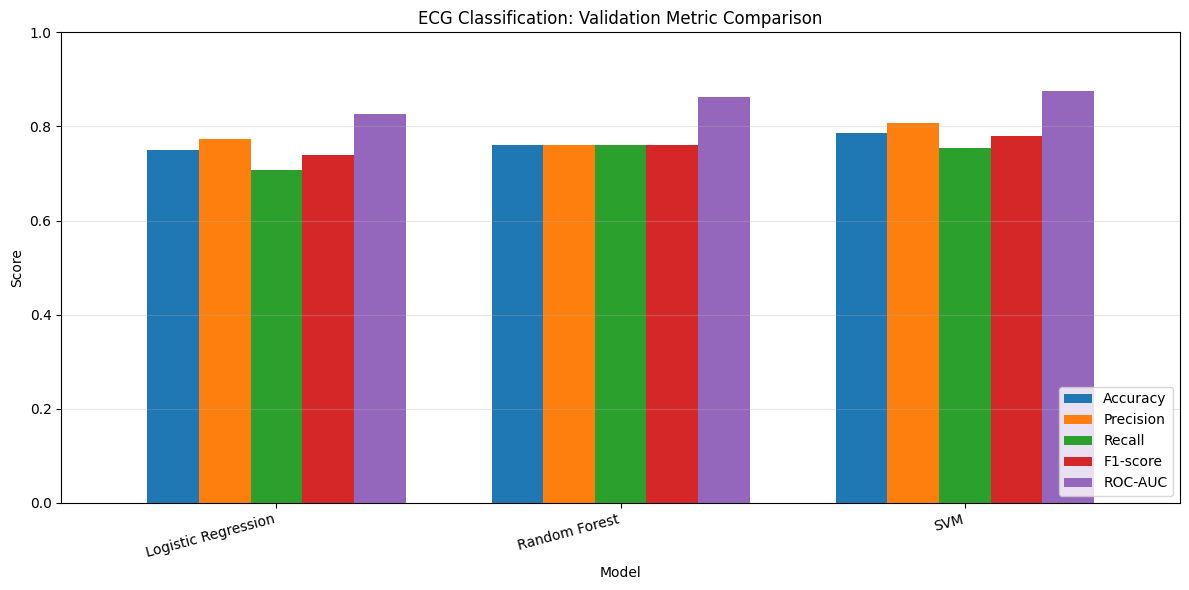

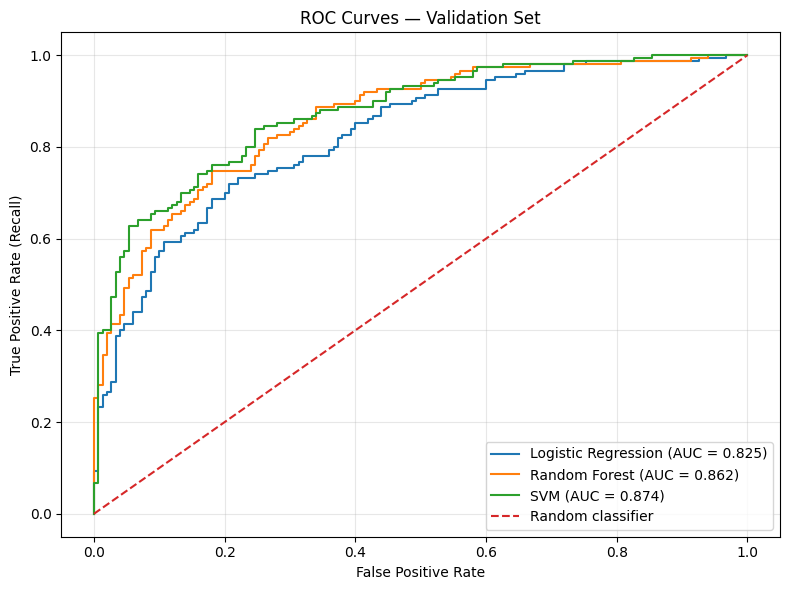

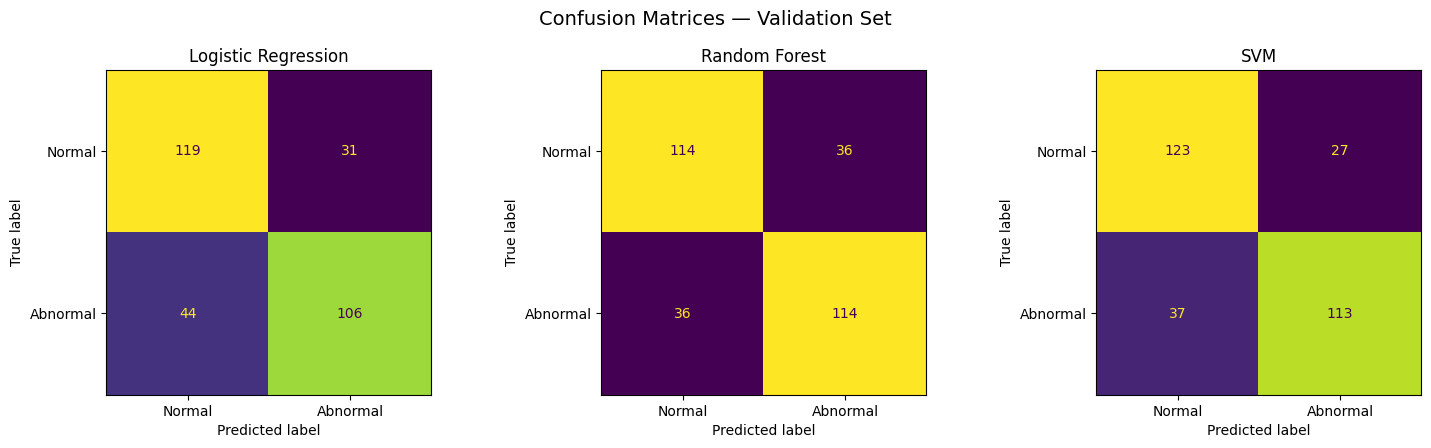

VALIDATION METRICS


TypeError: 'ConfusionMatrixDisplay' object is not callable

In [52]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

# Use validation data only for this visualization
models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "SVM": svm_model
}

colors = None  # Use Matplotlib's default color cycle

# Collect predictions and metrics
metrics = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    pred = model.predict(X_val)
    prob = model.predict_proba(X_val)[:, 1]

    predictions[name] = pred
    probabilities[name] = prob

    metrics[name] = {
        "Accuracy": accuracy_score(y_val, pred),
        "Precision": precision_score(
            y_val, pred, zero_division=0
        ),
        "Recall": recall_score(
            y_val, pred, zero_division=0
        ),
        "F1-score": f1_score(
            y_val, pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_val, prob)
    }

metrics_df = pd.DataFrame(metrics).T

# --------------------------------------------------
# 1. Compare all five metrics
# --------------------------------------------------
ax = metrics_df.plot(
    kind="bar",
    figsize=(12, 6),
    ylim=(0, 1),
    width=0.75
)

ax.set_title("ECG Classification: Validation Metric Comparison")
ax.set_ylabel("Score")
ax.set_xlabel("Model")
ax.set_xticklabels(metrics_df.index, rotation=15, ha="right")
ax.grid(axis="y", alpha=0.3)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 2. ROC curves
# --------------------------------------------------
plt.figure(figsize=(8, 6))

for name, prob in probabilities.items():
    fpr, tpr, _ = roc_curve(y_val, prob)
    auc = roc_auc_score(y_val, prob)

    plt.plot(
        fpr, tpr,
        label=f"{name} (AUC = {auc:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curves — Validation Set")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 3. Confusion matrices
# --------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (name, pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_val, pred, labels=[0, 1])

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Normal", "Abnormal"]
    )

    display.plot(
        ax=ax,
        values_format="d",
        colorbar=False
    )

    ax.set_title(name)

fig.suptitle("Confusion Matrices — Validation Set", fontsize=14)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Print the exact metric table
# --------------------------------------------------
print("VALIDATION METRICS")
display(metrics_df.round(4))


In [50]:

from IPython.display import display as show_output

print("VALIDATION METRICS")
show_output(metrics_df.round(4))


VALIDATION METRICS


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Logistic Regression,0.7500,0.7737,0.7067,0.7387,0.8255
Random Forest,0.7600,0.7600,0.7600,0.7600,0.8624
SVM,0.7867,0.8071,0.7533,0.7793,0.8744


In [51]:
cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Abnormal"]
)

cm_display.plot(ax=ax, values_format="d", colorbar=False)

**Tune the three models**

In [53]:

import time
import pandas as pd

from sklearn.model_selection import RandomizedSearchCV, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Patient-grouped CV: the same patient cannot appear in
# both the internal training and validation folds.
cv = StratifiedGroupKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# Search spaces for each model
search_spaces = {
    "Logistic Regression": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("classifier", LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                random_state=42
            ))
        ]),
        "params": {
            "classifier__C": [0.01, 0.1, 1, 10, 100],
            "classifier__solver": ["lbfgs"]
        },
        "iterations": 5
    },

    "Random Forest": {
        "model": RandomForestClassifier(
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ),
        "params": {
            "n_estimators": [100, 200, 300, 400],
            "max_depth": [None, 10, 20, 30],
            "min_samples_leaf": [1, 2, 4, 8],
            "max_features": ["sqrt", 0.5]
        },
        "iterations": 10
    },

    "SVM": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("classifier", SVC(
                kernel="rbf",
                class_weight="balanced",
                probability=True,
                random_state=42
            ))
        ]),
        "params": {
            "classifier__C": [0.1, 1, 10, 100],
            "classifier__gamma": ["scale", 0.001, 0.01, 0.1]
        },
        "iterations": 10
    }
}

tuned_models = {}
tuning_results = []

for name, config in search_spaces.items():
    print(f"\nTuning {name}...")
    start = time.perf_counter()

    search = RandomizedSearchCV(
        estimator=config["model"],
        param_distributions=config["params"],
        n_iter=config["iterations"],
        scoring="roc_auc",
        cv=cv,
        random_state=42,
        n_jobs=-1,
        refit=True,
        return_train_score=True,
        error_score="raise"
    )

    search.fit(
        X_train,
        y_train,
        groups=train_df["patient_id"]
    )

    elapsed = time.perf_counter() - start
    tuned_models[name] = search.best_estimator_

    tuning_results.append({
        "Model": name,
        "Best CV ROC-AUC": search.best_score_,
        "Search time (seconds)": round(elapsed, 2),
        "Best parameters": search.best_params_
    })

    print("Best CV ROC-AUC:", round(search.best_score_, 4))
    print("Best parameters:", search.best_params_)
    print("Search time:", round(elapsed, 2), "seconds")

tuning_df = pd.DataFrame(tuning_results)

print("\nTUNING SUMMARY")
display(tuning_df[[
    "Model", "Best CV ROC-AUC", "Search time (seconds)"
]].round(4))

print("\nFull best-parameter details:")
for row in tuning_results:
    print(f"\n{row['Model']}: {row['Best parameters']}")



Tuning Logistic Regression...
Best CV ROC-AUC: 0.8223
Best parameters: {'classifier__solver': 'lbfgs', 'classifier__C': 100}
Search time: 7.54 seconds

Tuning Random Forest...
Best CV ROC-AUC: 0.8349
Best parameters: {'n_estimators': 200, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20}
Search time: 372.54 seconds

Tuning SVM...
Best CV ROC-AUC: 0.8503
Best parameters: {'classifier__gamma': 'scale', 'classifier__C': 10}
Search time: 44.02 seconds

TUNING SUMMARY


TypeError: 'ConfusionMatrixDisplay' object is not callable

In [54]:

from IPython.display import display as show_output

print("TUNING SUMMARY")
show_output(
    tuning_df[
        ["Model", "Best CV ROC-AUC", "Search time (seconds)"]
    ].round(4)
)

print("\nBEST PARAMETERS")
for row in tuning_results:
    print(f"\n{row['Model']}:")
    print(row["Best parameters"])


TUNING SUMMARY


,Model,Best CV ROC-AUC,Search time (seconds)
0,Logistic Regression,0.8223,7.54
1,Random Forest,0.8349,372.54
2,SVM,0.8503,44.02



BEST PARAMETERS

Logistic Regression:
{'classifier__solver': 'lbfgs', 'classifier__C': 100}

Random Forest:
{'n_estimators': 200, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20}

SVM:
{'classifier__gamma': 'scale', 'classifier__C': 10}


In [55]:

import json
from pathlib import Path

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/PRG4206_Arrhythmia_Project/processed"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Save summary table
tuning_df.to_csv(OUTPUT_DIR / "hyperparameter_tuning_summary.csv", index=False)

# Save full best-parameter configurations
with open(OUTPUT_DIR / "best_hyperparameters.json", "w") as f:
    json.dump(
        {row["Model"]: row["Best parameters"] for row in tuning_results},
        f,
        indent=2
    )

print("Saved tuning summary and best parameters to:", OUTPUT_DIR)


Saved tuning summary and best parameters to: /content/drive/MyDrive/PRG4206_Arrhythmia_Project/processed


In [56]:

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)
import pandas as pd

# Evaluate tuned models on validation fold 9 only
tuned_validation_results = []

for name, model in tuned_models.items():
    pred = model.predict(X_val)
    prob = model.predict_proba(X_val)[:, 1]

    tuned_validation_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, pred),
        "Precision": precision_score(
            y_val, pred, zero_division=0
        ),
        "Recall": recall_score(
            y_val, pred, zero_division=0
        ),
        "F1-score": f1_score(
            y_val, pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_val, prob)
    })

tuned_validation_df = pd.DataFrame(
    tuned_validation_results
).sort_values("ROC-AUC", ascending=False)

from IPython.display import display as show_output
show_output(tuned_validation_df.round(4))


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
1,Random Forest,0.7567,0.7550,0.7600,0.7575,0.8561
2,SVM,0.7867,0.7986,0.7667,0.7823,0.8552
0,Logistic Regression,0.7533,0.7714,0.7200,0.7448,0.8271


In [57]:

from pathlib import Path
import json
import joblib
import sklearn
import pandas as pd

PROJECT_DIR = Path(
    "/content/drive/MyDrive/PRG4206_Arrhythmia_Project"
)
MODEL_DIR = PROJECT_DIR / "models"
RESULT_DIR = PROJECT_DIR / "results"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# Save each tuned model
for name, model in tuned_models.items():
    filename = name.lower().replace(" ", "_") + "_tuned.joblib"
    joblib.dump(model, MODEL_DIR / filename)
    print("Saved:", MODEL_DIR / filename)

# Save validation comparison
tuned_validation_df.to_csv(
    RESULT_DIR / "tuned_model_validation_comparison.csv",
    index=False
)

# Save experiment metadata
metadata = {
    "project": "Explainable ECG Classification Using PTB-XL",
    "selected_candidate": "SVM",
    "selection_basis": "Validation results on official fold 9",
    "training_folds": list(range(1, 9)),
    "validation_fold": 9,
    "test_fold": 10,
    "random_seed": 42,
    "cross_validation": "3-fold StratifiedGroupKFold grouped by patient_id",
    "scikit_learn_version": sklearn.__version__,
    "best_parameters": {
        row["Model"]: row["Best parameters"]
        for row in tuning_results
    }
}

with open(RESULT_DIR / "experiment_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("\nSaved validation comparison and experiment metadata.")
print("Scikit-learn version:", sklearn.__version__)


Saved: /content/drive/MyDrive/PRG4206_Arrhythmia_Project/models/logistic_regression_tuned.joblib
Saved: /content/drive/MyDrive/PRG4206_Arrhythmia_Project/models/random_forest_tuned.joblib
Saved: /content/drive/MyDrive/PRG4206_Arrhythmia_Project/models/svm_tuned.joblib

Saved validation comparison and experiment metadata.
Scikit-learn version: 1.6.1


**Final test evaluation**

In [58]:

import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from IPython.display import display as show_output

test_results = []
test_predictions = {}
test_probabilities = {}
test_confusion_matrices = {}

for name, model in tuned_models.items():
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    # Labels: 0 = normal, 1 = abnormal
    tn, fp, fn, tp = confusion_matrix(
        y_test, pred, labels=[0, 1]
    ).ravel()

    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    test_predictions[name] = pred
    test_probabilities[name] = prob
    test_confusion_matrices[name] = np.array([
        [tn, fp],
        [fn, tp]
    ])

    test_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(
            y_test, pred, zero_division=0
        ),
        "Recall / Sensitivity": recall_score(
            y_test, pred, zero_division=0
        ),
        "Specificity": specificity,
        "F1-score": f1_score(
            y_test, pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_test, prob)
    })

test_results_df = pd.DataFrame(test_results)

print("FINAL TEST RESULTS — OFFICIAL FOLD 10")
show_output(test_results_df.round(4))

# Detailed results for each model
for name, pred in test_predictions.items():
    print(f"\n{name} — Confusion Matrix")
    print(test_confusion_matrices[name])

    print(f"\n{name} — Classification Report")
    print(classification_report(
        y_test,
        pred,
        labels=[0, 1],
        target_names=["Normal", "Abnormal"],
        zero_division=0
    ))

# Save results to Drive
from pathlib import Path

RESULT_DIR = Path(
    "/content/drive/MyDrive/PRG4206_Arrhythmia_Project/results"
)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

test_results_df.to_csv(
    RESULT_DIR / "final_test_results.csv",
    index=False
)

print("\nTest results saved to:", RESULT_DIR / "final_test_results.csv")


FINAL TEST RESULTS — OFFICIAL FOLD 10


,Model,Accuracy,Precision,Recall / Sensitivity,Specificity,F1-score,ROC-AUC
0,Logistic Regression,0.7659,0.8264,0.6711,0.8600,0.7407,0.8274
1,Random Forest,0.7692,0.8077,0.7047,0.8333,0.7527,0.8285
2,SVM,0.7358,0.8070,0.6174,0.8533,0.6996,0.8343



Logistic Regression — Confusion Matrix
[[129  21]
 [ 49 100]]

Logistic Regression — Classification Report
              precision    recall  f1-score   support

      Normal       0.72      0.86      0.79       150
    Abnormal       0.83      0.67      0.74       149

    accuracy                           0.77       299
   macro avg       0.78      0.77      0.76       299
weighted avg       0.78      0.77      0.76       299


Random Forest — Confusion Matrix
[[125  25]
 [ 44 105]]

Random Forest — Classification Report
              precision    recall  f1-score   support

      Normal       0.74      0.83      0.78       150
    Abnormal       0.81      0.70      0.75       149

    accuracy                           0.77       299
   macro avg       0.77      0.77      0.77       299
weighted avg       0.77      0.77      0.77       299


SVM — Confusion Matrix
[[128  22]
 [ 57  92]]

SVM — Classification Report
              precision    recall  f1-score   support

      Norma

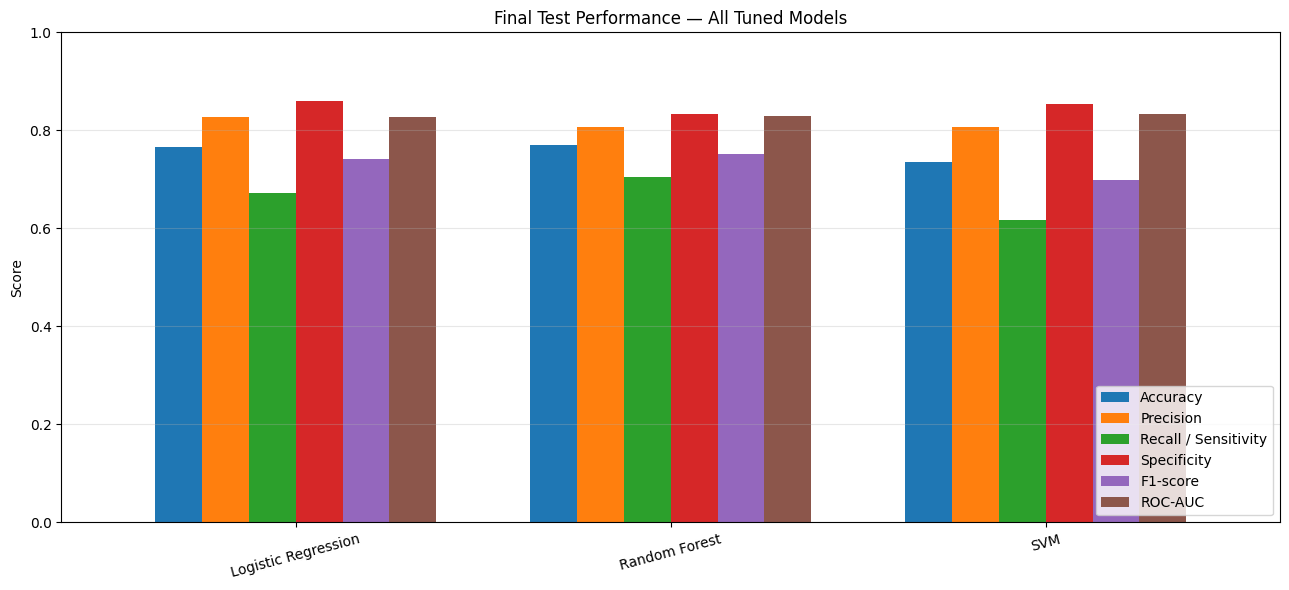

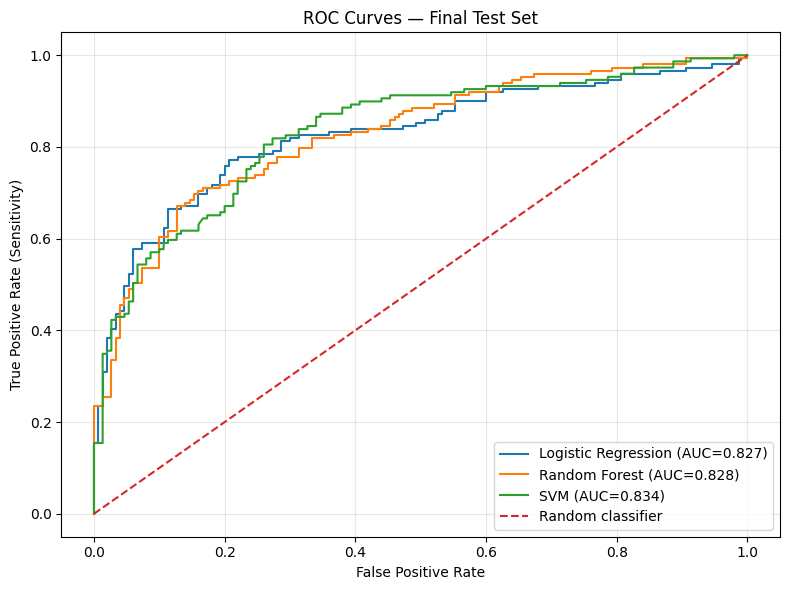

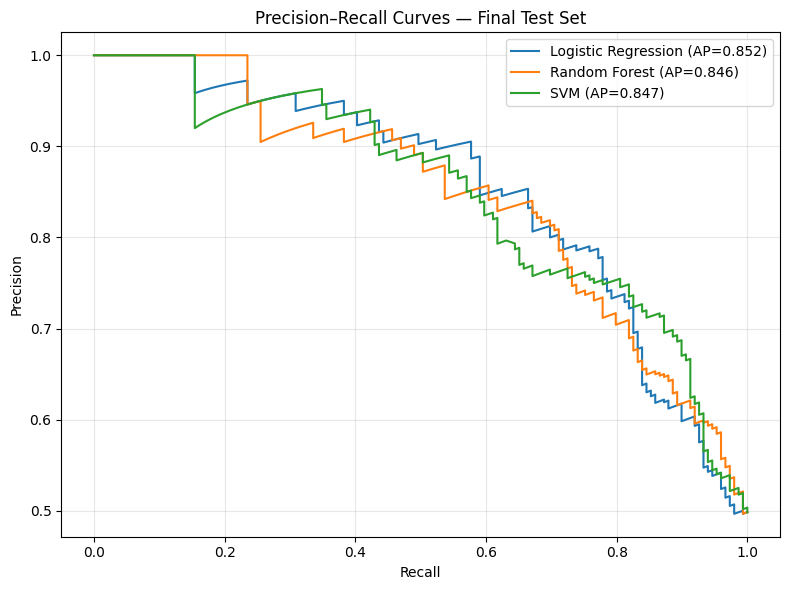

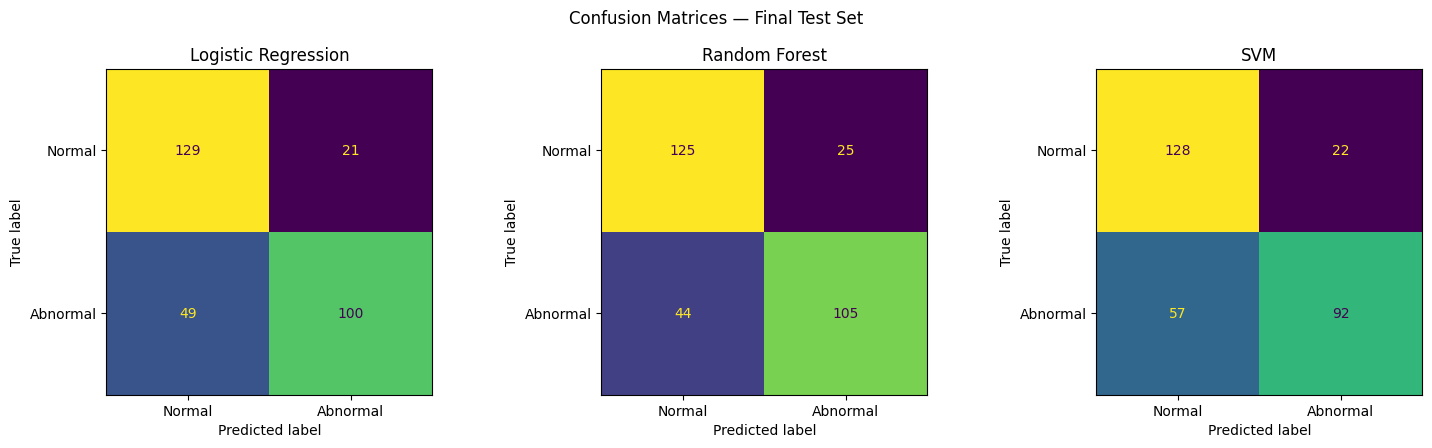

All figures saved to: /content/drive/MyDrive/PRG4206_Arrhythmia_Project/results


In [59]:

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    roc_curve, precision_recall_curve,
    average_precision_score, ConfusionMatrixDisplay
)

# 1. Compare final test metrics
metric_cols = [
    "Accuracy", "Precision", "Recall / Sensitivity",
    "Specificity", "F1-score", "ROC-AUC"
]

ax = test_results_df.set_index("Model")[metric_cols].plot(
    kind="bar", figsize=(13, 6), ylim=(0, 1), width=0.75
)
ax.set_title("Final Test Performance — All Tuned Models")
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=15)
ax.grid(axis="y", alpha=0.3)
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(RESULT_DIR / "final_test_metric_comparison.png",
            dpi=300, bbox_inches="tight")
plt.show()

# 2. ROC curves
plt.figure(figsize=(8, 6))

for name, prob in test_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = test_results_df.loc[
        test_results_df["Model"] == name, "ROC-AUC"
    ].iloc[0]
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curves — Final Test Set")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULT_DIR / "final_test_roc_curves.png",
            dpi=300, bbox_inches="tight")
plt.show()

# 3. Precision–recall curves
plt.figure(figsize=(8, 6))

for name, prob in test_probabilities.items():
    precision, recall, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves — Final Test Set")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULT_DIR / "final_test_precision_recall.png",
            dpi=300, bbox_inches="tight")
plt.show()

# 4. Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (name, cm) in zip(axes, test_confusion_matrices.items()):
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Normal", "Abnormal"]
    ).plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(name)

fig.suptitle("Confusion Matrices — Final Test Set")
plt.tight_layout()
plt.savefig(RESULT_DIR / "final_test_confusion_matrices.png",
            dpi=300, bbox_inches="tight")
plt.show()

print("All figures saved to:", RESULT_DIR)


# Explainable AI (XAI)

**Global feature importance**

Model: Tuned SVM
Validation records: 300
Features: 96

Top 15 features by permutation importance:


,Feature,Importance_Mean,Importance_Std
28,AVR_median,0.02850,0.00815
36,AVL_median,0.02810,0.00863
60,V2_median,0.02318,0.00467
76,V4_median,0.02086,0.00451
3,I_max,0.01991,0.00172
84,V5_median,0.01964,0.00940
68,V3_median,0.01664,0.00079
83,V5_max,0.01469,0.01104
82,V5_min,0.01130,0.00378
75,V4_max,0.00970,0.00370


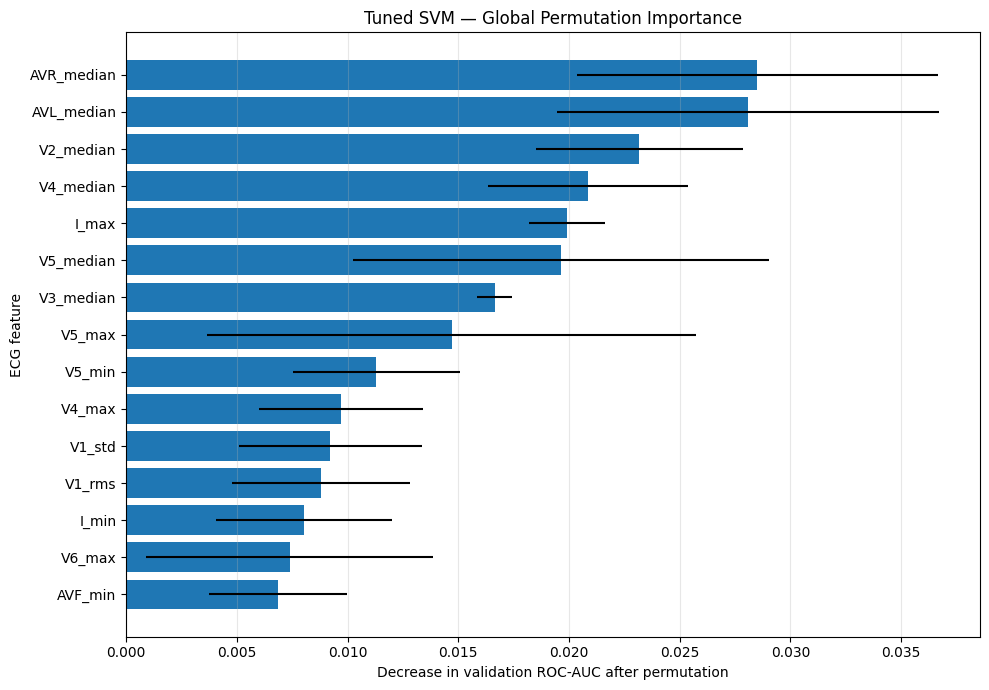

Saved figure and table to: /content/drive/MyDrive/PRG4206_Arrhythmia_Project/results


In [60]:

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.inspection import permutation_importance

# Current validation-selected candidate
xai_model = tuned_models["SVM"]

# Keep only model input features
feature_cols = [
    c for c in features_df.columns
    if c not in ["ecg_id", "patient_id", "strat_fold", "target"]
]

X_val_xai = X_val[feature_cols]

print("Model: Tuned SVM")
print("Validation records:", len(X_val_xai))
print("Features:", len(feature_cols))

# Permutation importance measured by ROC-AUC
perm = permutation_importance(
    xai_model,
    X_val_xai,
    y_val,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance_Mean": perm.importances_mean,
    "Importance_Std": perm.importances_std
}).sort_values("Importance_Mean", ascending=False)

# Display top features
from IPython.display import display as show_output

print("\nTop 15 features by permutation importance:")
show_output(importance_df.head(15).round(5))

# Plot top 15 features
top = importance_df.head(15).sort_values("Importance_Mean")

plt.figure(figsize=(10, 7))
plt.barh(
    top["Feature"],
    top["Importance_Mean"],
    xerr=top["Importance_Std"]
)
plt.xlabel("Decrease in validation ROC-AUC after permutation")
plt.ylabel("ECG feature")
plt.title("Tuned SVM — Global Permutation Importance")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

RESULT_DIR = Path(
    "/content/drive/MyDrive/PRG4206_Arrhythmia_Project/results"
)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

plt.savefig(
    RESULT_DIR / "svm_permutation_importance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

importance_df.to_csv(
    RESULT_DIR / "svm_permutation_importance.csv",
    index=False
)

print("Saved figure and table to:", RESULT_DIR)


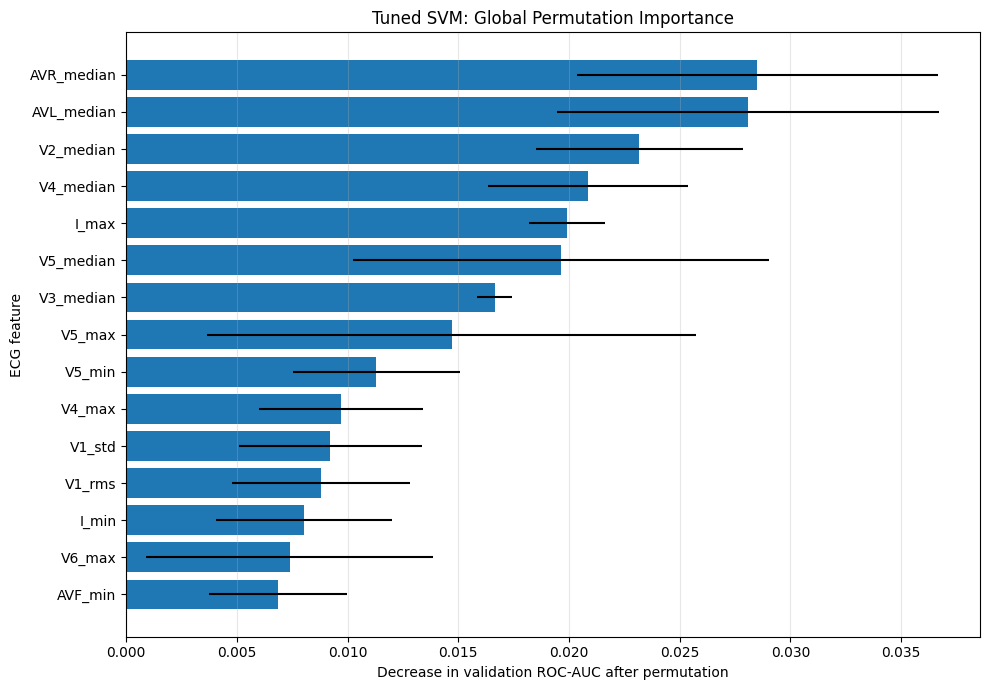

SVG saved: /content/drive/MyDrive/PRG4206_Arrhythmia_Project/results/svm_permutation_importance_top15.svg
PNG saved: /content/drive/MyDrive/PRG4206_Arrhythmia_Project/results/svm_permutation_importance_top15.png


In [61]:

import matplotlib.pyplot as plt
from pathlib import Path

RESULT_DIR = Path(
    "/content/drive/MyDrive/PRG4206_Arrhythmia_Project/results"
)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# Top 15 features, ordered for a horizontal bar chart
top15 = importance_df.head(15).sort_values("Importance_Mean")

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    top15["Feature"],
    top15["Importance_Mean"],
    xerr=top15["Importance_Std"]
)
ax.set_xlabel("Decrease in validation ROC-AUC after permutation")
ax.set_ylabel("ECG feature")
ax.set_title("Tuned SVM: Global Permutation Importance")
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()

# Save vector SVG and high-resolution PNG
fig.savefig(
    RESULT_DIR / "svm_permutation_importance_top15.svg",
    format="svg",
    bbox_inches="tight"
)
fig.savefig(
    RESULT_DIR / "svm_permutation_importance_top15.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("SVG saved:", RESULT_DIR / "svm_permutation_importance_top15.svg")
print("PNG saved:", RESULT_DIR / "svm_permutation_importance_top15.png")


**Explain individual ECG predictions using SHAP**

Selected validation examples:


,Example,True class,Predicted class,Predicted abnormal probability
0,Correct_Normal,Normal,Normal,0.0370
1,Correct_Abnormal,Abnormal,Abnormal,0.9334
2,Misclassified,Abnormal,Normal,0.3885



Calculating SHAP values. This may take a few minutes...


  0%|          | 0/3 [00:00<?, ?it/s]

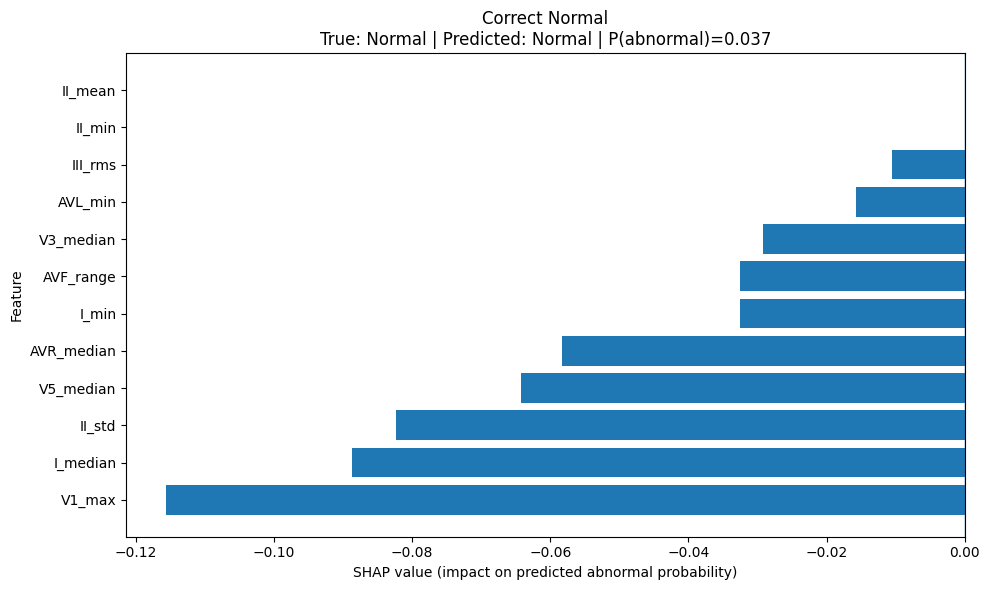

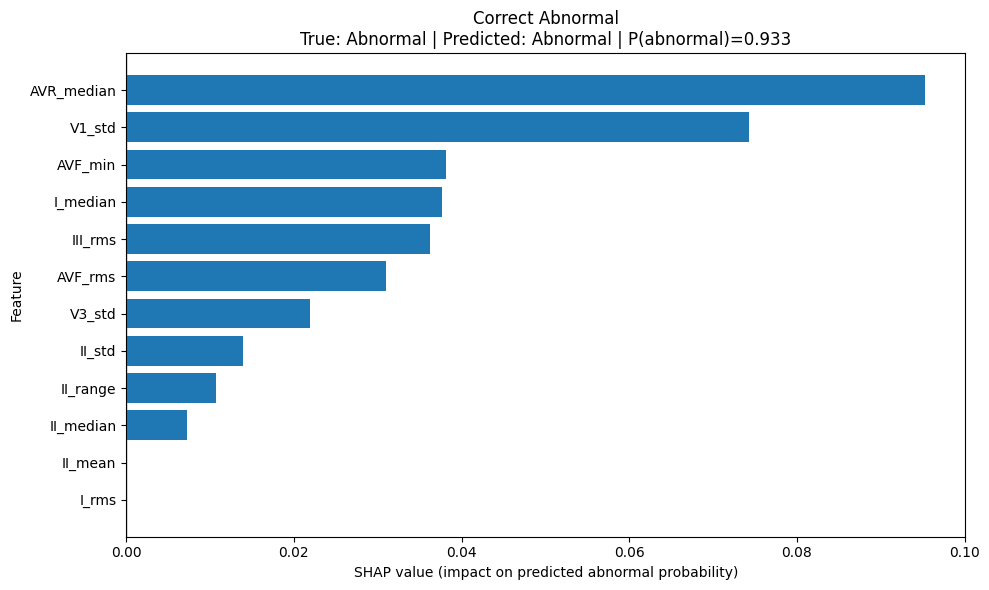

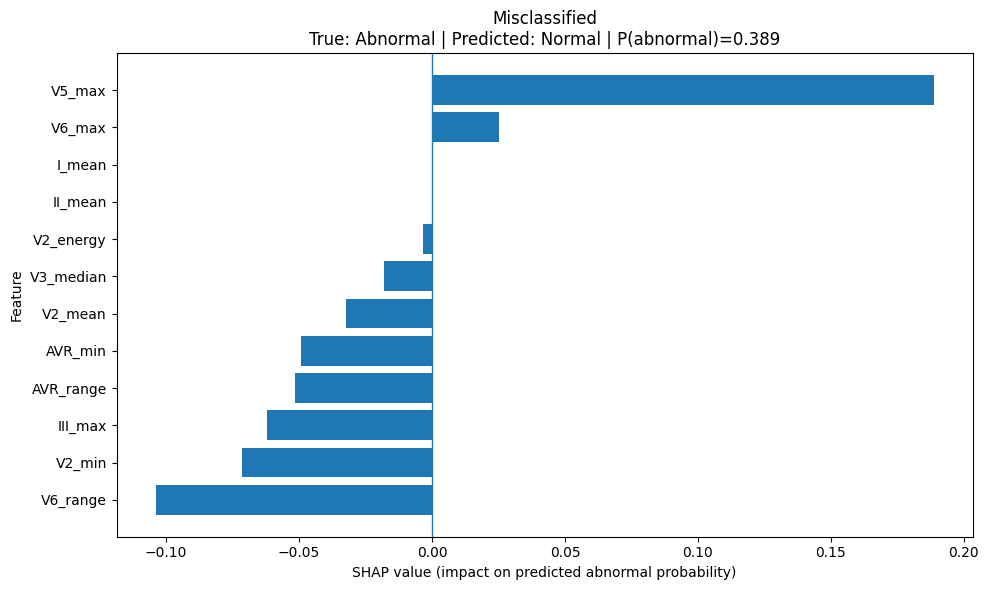


Saved SHAP charts and feature tables to:
/content/drive/MyDrive/PRG4206_Arrhythmia_Project/results


In [62]:

# STEP 19: SHAP explanations for 3 individual ECG predictions

!pip -q install shap

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from IPython.display import display as show_output

# Save outputs
RESULT_DIR = "/content/drive/MyDrive/PRG4206_Arrhythmia_Project/results"
os.makedirs(RESULT_DIR, exist_ok=True)

# Use the tuned SVM and validation data
svm_model = tuned_models["SVM"]

# Convert labels to arrays for reliable position-based selection
y_true = np.asarray(y_val).astype(int)
y_pred = svm_model.predict(X_val).astype(int)
y_prob = svm_model.predict_proba(X_val)[:, 1]

# Select representative examples:
# 0 = Normal, 1 = Abnormal
normal_correct = np.flatnonzero((y_true == 0) & (y_pred == 0))
abnormal_correct = np.flatnonzero((y_true == 1) & (y_pred == 1))
misclassified = np.flatnonzero(y_true != y_pred)

selected = {}

if len(normal_correct):
    selected["Correct_Normal"] = normal_correct[0]

if len(abnormal_correct):
    selected["Correct_Abnormal"] = abnormal_correct[0]

if len(misclassified):
    selected["Misclassified"] = misclassified[0]

if not selected:
    raise ValueError("No suitable validation examples were found.")

print("Selected validation examples:")
summary = []

for label, pos in selected.items():
    summary.append({
        "Example": label,
        "True class": "Abnormal" if y_true[pos] == 1 else "Normal",
        "Predicted class": "Abnormal" if y_pred[pos] == 1 else "Normal",
        "Predicted abnormal probability": round(float(y_prob[pos]), 4)
    })

show_output(pd.DataFrame(summary))

# Background data for SHAP: a small sample from training data
background = shap.sample(X_train, min(20, len(X_train)), random_state=42)

# Use only the abnormal-class probability as the output being explained
feature_names = list(X_train.columns)

def abnormal_probability(data):
    data_df = pd.DataFrame(data, columns=feature_names)
    return svm_model.predict_proba(data_df)[:, 1]

explainer = shap.KernelExplainer(abnormal_probability, background)

positions = list(selected.values())
X_examples = X_val.iloc[positions]

print("\nCalculating SHAP values. This may take a few minutes...")

shap_raw = explainer.shap_values(X_examples, nsamples=100)
shap_values = np.asarray(shap_raw)

# Standardize output shape across SHAP versions
if shap_values.ndim == 3:
    if shap_values.shape[0] == len(positions):
        shap_values = shap_values[:, :, 0]
    elif shap_values.shape[-1] == len(positions):
        shap_values = np.moveaxis(shap_values, -1, 0)[:, :, 0]

if shap_values.ndim != 2:
    raise ValueError(f"Unexpected SHAP output shape: {shap_values.shape}")

# Save local explanations as both SVG and PNG
for row_num, (example_name, pos) in enumerate(selected.items()):
    values = shap_values[row_num]
    feature_values = X_examples.iloc[row_num].to_numpy()

    local_df = pd.DataFrame({
        "Feature": feature_names,
        "SHAP value": values,
        "Feature value": feature_values
    })
    local_df["Absolute SHAP"] = local_df["SHAP value"].abs()
    local_df = local_df.sort_values("Absolute SHAP", ascending=False)

    # Display the 12 most influential features for this ECG
    plot_df = local_df.head(12).sort_values("SHAP value")

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(plot_df["Feature"], plot_df["SHAP value"])
    ax.axvline(0, linewidth=1)
    ax.set_xlabel("SHAP value (impact on predicted abnormal probability)")
    ax.set_ylabel("Feature")
    ax.set_title(
        f"{example_name.replace('_', ' ')}\n"
        f"True: {'Abnormal' if y_true[pos] else 'Normal'} | "
        f"Predicted: {'Abnormal' if y_pred[pos] else 'Normal'} | "
        f"P(abnormal)={y_prob[pos]:.3f}"
    )
    fig.tight_layout()

    filename = f"shap_{example_name.lower()}"
    fig.savefig(os.path.join(RESULT_DIR, filename + ".png"),
                dpi=200, bbox_inches="tight")
    fig.savefig(os.path.join(RESULT_DIR, filename + ".svg"),
                format="svg", bbox_inches="tight")
    plt.show()

    local_df.drop(columns="Absolute SHAP").to_csv(
        os.path.join(RESULT_DIR, filename + ".csv"), index=False
    )

print(f"\nSaved SHAP charts and feature tables to:\n{RESULT_DIR}")


**Error analysis and visualizations**

Validation error summary:


,True negatives,False positives,False negatives,True positives,Sensitivity / Recall,Specificity,Validation errors,Error rate
0,121,29,35,115,0.7667,0.8067,64,0.2133



Misclassified validation records:


,validation_position,actual_class,predicted_class,abnormal_probability,error_type,ecg_id,patient_id,strat_fold
0,2,1,0,0.3885,False Negative,2494,15380.0,9
1,3,0,1,0.6939,False Positive,5900,13771.0,9
2,7,1,0,0.3849,False Negative,16687,10556.0,9
3,14,1,0,0.0773,False Negative,8439,5534.0,9
4,32,0,1,0.7037,False Positive,2056,6309.0,9
5,38,0,1,0.7964,False Positive,14484,16996.0,9
6,44,1,0,0.4150,False Negative,19366,16259.0,9
7,48,0,1,0.5769,False Positive,12700,4179.0,9
8,49,1,0,0.2401,False Negative,13616,11973.0,9
9,53,0,1,0.5926,False Positive,7091,1866.0,9


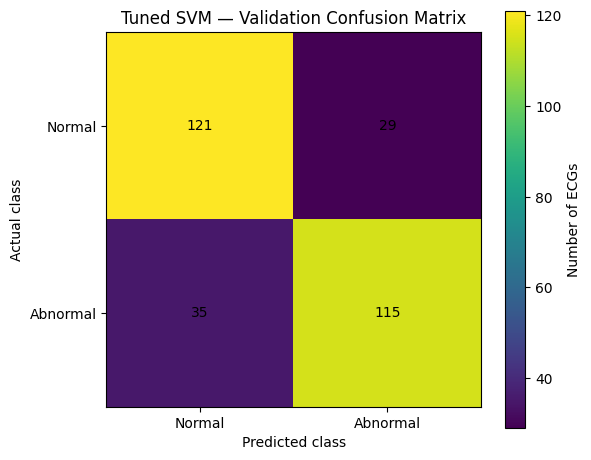

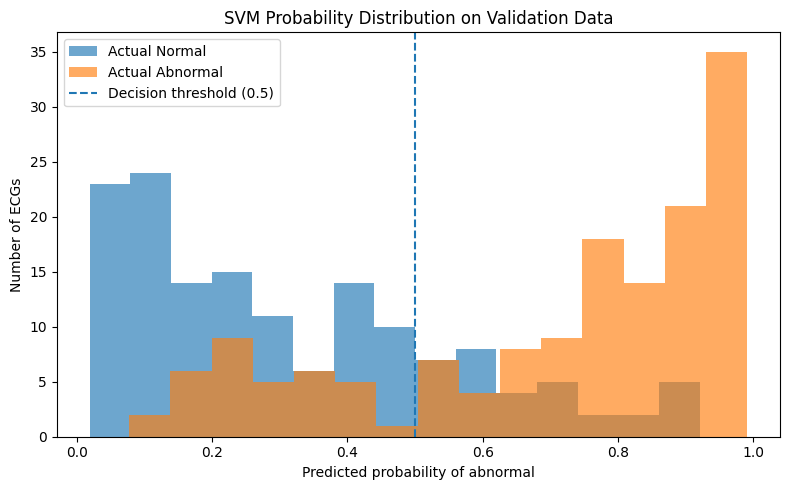

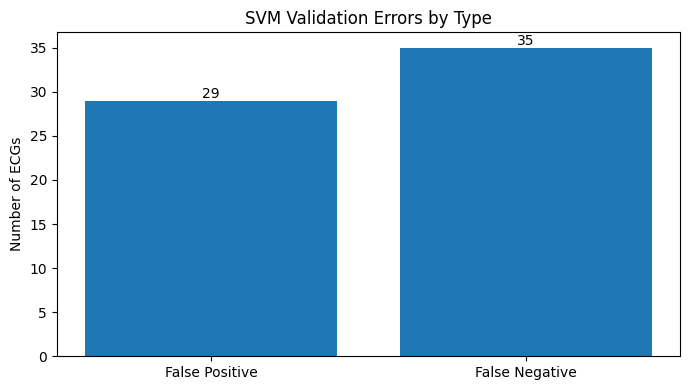

Saved error-analysis tables and charts in: /content/drive/MyDrive/PRG4206_Arrhythmia_Project/results


In [63]:

# STEP 20: Validation error analysis

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from IPython.display import display as show_output

RESULT_DIR = "/content/drive/MyDrive/PRG4206_Arrhythmia_Project/results"
os.makedirs(RESULT_DIR, exist_ok=True)

# Recalculate predictions consistently
y_true = np.asarray(y_val).astype(int)
y_pred = tuned_models["SVM"].predict(X_val).astype(int)
y_prob = tuned_models["SVM"].predict_proba(X_val)[:, 1]

# Confusion matrix: rows = actual, columns = predicted
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp) if (tn + fp) else 0
sensitivity = tp / (tp + fn) if (tp + fn) else 0

metrics = pd.DataFrame([{
    "True negatives": tn,
    "False positives": fp,
    "False negatives": fn,
    "True positives": tp,
    "Sensitivity / Recall": sensitivity,
    "Specificity": specificity,
    "Validation errors": fp + fn,
    "Error rate": (fp + fn) / len(y_true)
}])

print("Validation error summary:")
show_output(metrics.round(4))

# Build a table of misclassified records
errors = np.flatnonzero(y_true != y_pred)

error_df = pd.DataFrame({
    "validation_position": errors,
    "actual_class": y_true[errors],
    "predicted_class": y_pred[errors],
    "abnormal_probability": y_prob[errors],
})

error_df["error_type"] = np.where(
    error_df["actual_class"] == 1,
    "False Negative",
    "False Positive"
)

# Add identifiers if available in val_df
if "val_df" in globals():
    for col in ["ecg_id", "patient_id", "strat_fold"]:
        if col in val_df.columns:
            error_df[col] = val_df.iloc[errors][col].to_numpy()

print("\nMisclassified validation records:")
show_output(error_df.head(20).round(4))

# Save all validation errors
error_df.to_csv(
    os.path.join(RESULT_DIR, "svm_validation_errors.csv"),
    index=False
)
metrics.to_csv(
    os.path.join(RESULT_DIR, "svm_validation_error_summary.csv"),
    index=False
)

# Visual 1: confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm)

ax.set_xticks([0, 1], labels=["Normal", "Abnormal"])
ax.set_yticks([0, 1], labels=["Normal", "Abnormal"])
ax.set_xlabel("Predicted class")
ax.set_ylabel("Actual class")
ax.set_title("Tuned SVM — Validation Confusion Matrix")

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center")

fig.colorbar(im, ax=ax, label="Number of ECGs")
fig.tight_layout()

for ext in ["png", "svg"]:
    fig.savefig(
        os.path.join(RESULT_DIR, f"svm_validation_confusion_matrix.{ext}"),
        bbox_inches="tight"
    )
plt.show()

# Visual 2: predicted abnormal probabilities by actual class
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(y_prob[y_true == 0], bins=15, alpha=0.65, label="Actual Normal")
ax.hist(y_prob[y_true == 1], bins=15, alpha=0.65, label="Actual Abnormal")
ax.axvline(0.5, linestyle="--", label="Decision threshold (0.5)")

ax.set_xlabel("Predicted probability of abnormal")
ax.set_ylabel("Number of ECGs")
ax.set_title("SVM Probability Distribution on Validation Data")
ax.legend()
fig.tight_layout()

for ext in ["png", "svg"]:
    fig.savefig(
        os.path.join(RESULT_DIR, f"svm_validation_probability_distribution.{ext}"),
        bbox_inches="tight"
    )
plt.show()

# Visual 3: types of validation errors
error_counts = error_df["error_type"].value_counts().reindex(
    ["False Positive", "False Negative"], fill_value=0
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(error_counts.index, error_counts.values)
ax.set_ylabel("Number of ECGs")
ax.set_title("SVM Validation Errors by Type")

for i, value in enumerate(error_counts.values):
    ax.text(i, value, str(value), ha="center", va="bottom")

fig.tight_layout()

for ext in ["png", "svg"]:
    fig.savefig(
        os.path.join(RESULT_DIR, f"svm_validation_error_types.{ext}"),
        bbox_inches="tight"
    )
plt.show()

print(f"Saved error-analysis tables and charts in: {RESULT_DIR}")


**Final evaluation on the untouched test set**

FINAL TEST-SET RESULTS


,Model,Accuracy,Precision,Sensitivity,Specificity,F1,ROC-AUC,TN,FP,FN,TP
2,SVM,0.7358,0.8070,0.6174,0.8533,0.6996,0.8343,128,22,57,92
1,Random Forest,0.7692,0.8077,0.7047,0.8333,0.7527,0.8285,125,25,44,105
0,Logistic Regression,0.7659,0.8264,0.6711,0.8600,0.7407,0.8274,129,21,49,100


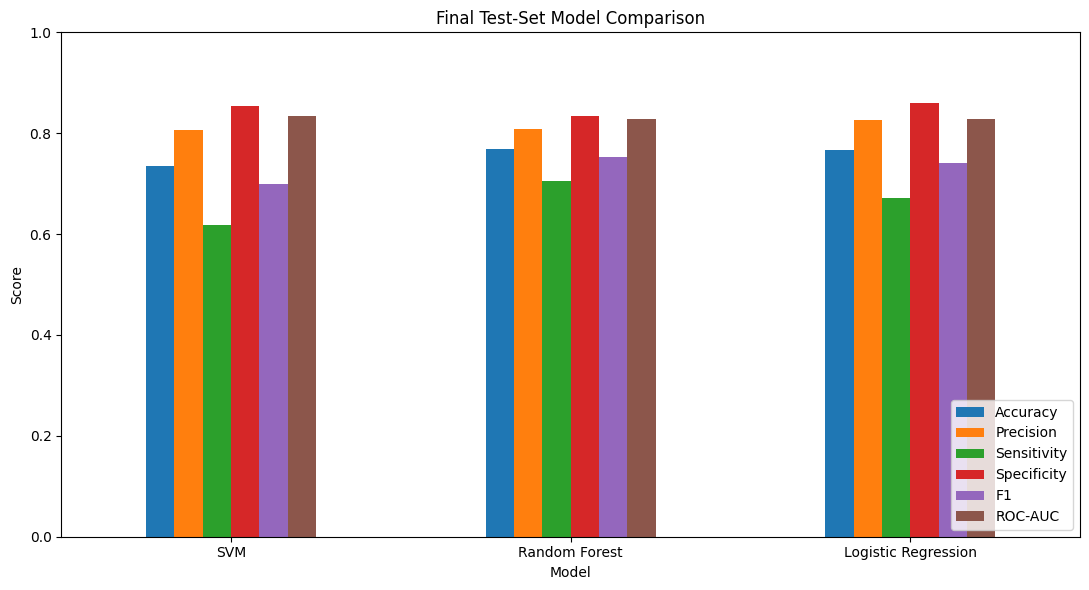

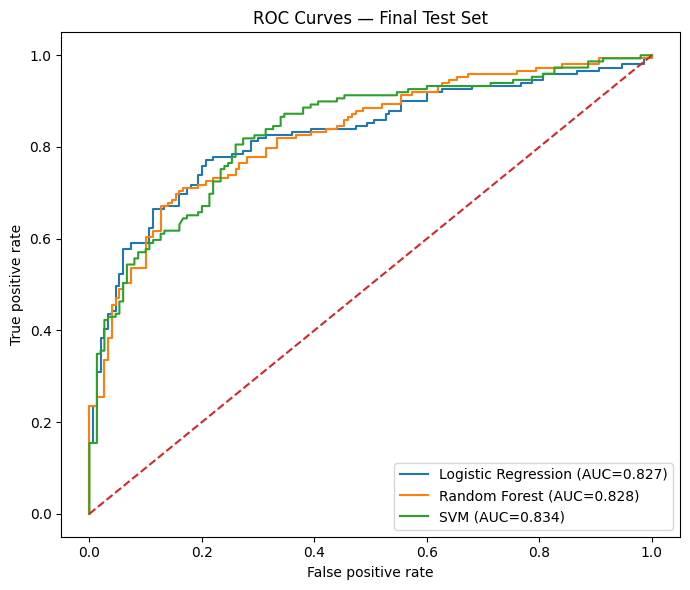

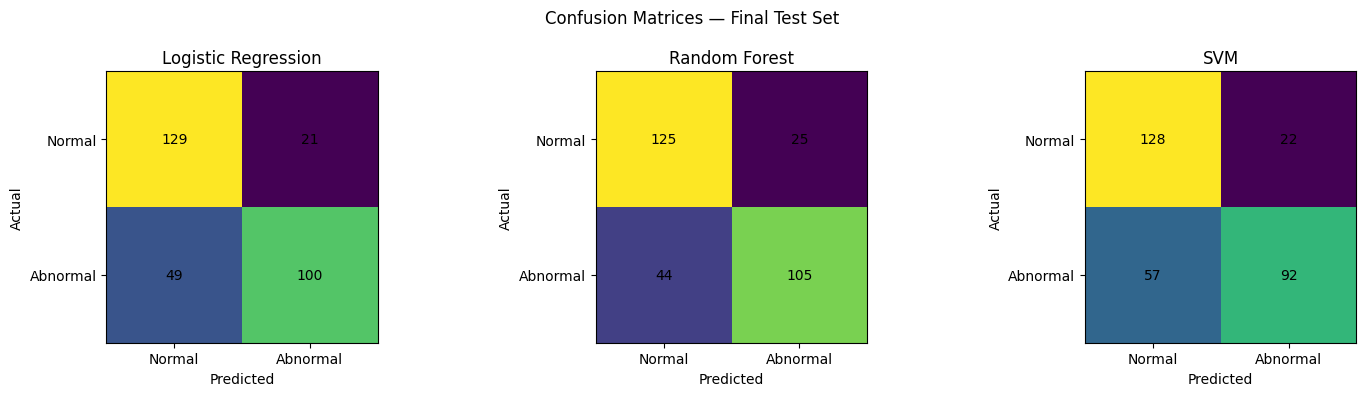

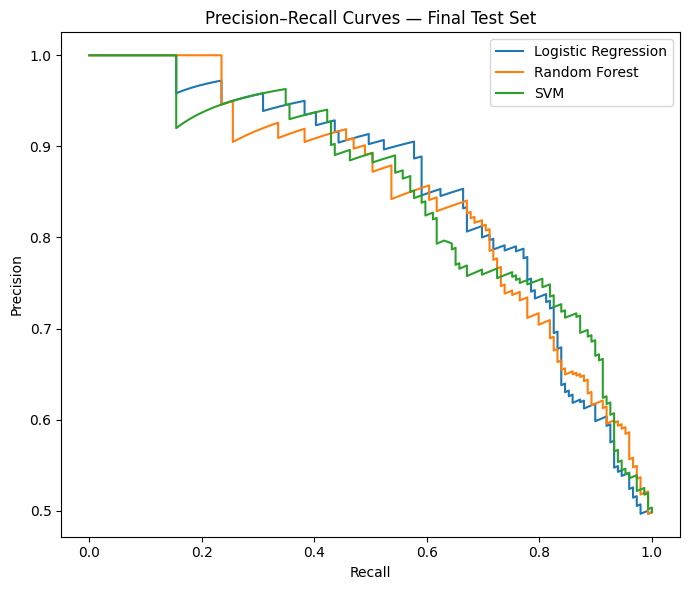

Results and SVG/PNG figures saved in:
/content/drive/MyDrive/PRG4206_Arrhythmia_Project/results


In [64]:

# STEP 22: Final test-set evaluation and SVG visualizations

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve
)
from IPython.display import display as show_output

RESULT_DIR = "/content/drive/MyDrive/PRG4206_Arrhythmia_Project/results"
os.makedirs(RESULT_DIR, exist_ok=True)

y_test_array = np.asarray(y_test).astype(int)

results = []
test_predictions = {}
test_probabilities = {}
test_confusion_matrices = {}

for name, model in tuned_models.items():
    predictions = model.predict(X_test).astype(int)
    probabilities = model.predict_proba(X_test)[:, 1]
    cm = confusion_matrix(y_test_array, predictions, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    test_predictions[name] = predictions
    test_probabilities[name] = probabilities
    test_confusion_matrices[name] = cm

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_array, predictions),
        "Precision": precision_score(y_test_array, predictions, zero_division=0),
        "Sensitivity": recall_score(y_test_array, predictions, zero_division=0),
        "Specificity": tn / (tn + fp) if tn + fp else 0,
        "F1": f1_score(y_test_array, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test_array, probabilities),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

test_results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False)

print("FINAL TEST-SET RESULTS")
show_output(test_results_df.round(4))

test_results_df.to_csv(
    os.path.join(RESULT_DIR, "final_test_results.csv"), index=False
)

# Visual 1: compare model metrics
metric_cols = ["Accuracy", "Precision", "Sensitivity",
               "Specificity", "F1", "ROC-AUC"]

ax = test_results_df.set_index("Model")[metric_cols].plot(
    kind="bar", figsize=(11, 6), ylim=(0, 1), rot=0
)
ax.set_title("Final Test-Set Model Comparison")
ax.set_ylabel("Score")
ax.legend(loc="lower right")
plt.tight_layout()

for ext in ["png", "svg"]:
    plt.savefig(
        os.path.join(RESULT_DIR, f"final_test_metric_comparison.{ext}"),
        bbox_inches="tight"
    )
plt.show()

# Visual 2: ROC curves
fig, ax = plt.subplots(figsize=(7, 6))

for name, probabilities in test_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test_array, probabilities)
    auc = roc_auc_score(y_test_array, probabilities)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC Curves — Final Test Set")
ax.legend()
fig.tight_layout()

for ext in ["png", "svg"]:
    fig.savefig(
        os.path.join(RESULT_DIR, f"final_test_roc_curves.{ext}"),
        bbox_inches="tight"
    )
plt.show()

# Visual 3: confusion matrices for each model
fig, axes = plt.subplots(1, len(test_confusion_matrices), figsize=(5 * len(test_confusion_matrices), 4))
axes = np.atleast_1d(axes)

for ax, (name, cm) in zip(axes, test_confusion_matrices.items()):
    ax.imshow(cm)
    ax.set_title(name)
    ax.set_xticks([0, 1], labels=["Normal", "Abnormal"])
    ax.set_yticks([0, 1], labels=["Normal", "Abnormal"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")

fig.suptitle("Confusion Matrices — Final Test Set")
fig.tight_layout()

for ext in ["png", "svg"]:
    fig.savefig(
        os.path.join(RESULT_DIR, f"final_test_confusion_matrices.{ext}"),
        bbox_inches="tight"
    )
plt.show()

# Visual 4: precision-recall curves
fig, ax = plt.subplots(figsize=(7, 6))

for name, probabilities in test_probabilities.items():
    precision, recall, _ = precision_recall_curve(
        y_test_array, probabilities
    )
    ax.plot(recall, precision, label=name)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision–Recall Curves — Final Test Set")
ax.legend()
fig.tight_layout()

for ext in ["png", "svg"]:
    fig.savefig(
        os.path.join(RESULT_DIR, f"final_test_precision_recall.{ext}"),
        bbox_inches="tight"
    )
plt.show()

print(f"Results and SVG/PNG figures saved in:\n{RESULT_DIR}")


**Compare validation vs test performance**

,Model,Split,N,Accuracy,Precision,Sensitivity,F1,ROC-AUC
0,Logistic Regression,Validation,300,0.7533,0.7714,0.7200,0.7448,0.8271
1,Logistic Regression,Test,299,0.7659,0.8264,0.6711,0.7407,0.8274
2,Random Forest,Validation,300,0.7567,0.7550,0.7600,0.7575,0.8561
3,Random Forest,Test,299,0.7692,0.8077,0.7047,0.7527,0.8285
4,SVM,Validation,300,0.7867,0.7986,0.7667,0.7823,0.8552
5,SVM,Test,299,0.7358,0.8070,0.6174,0.6996,0.8343


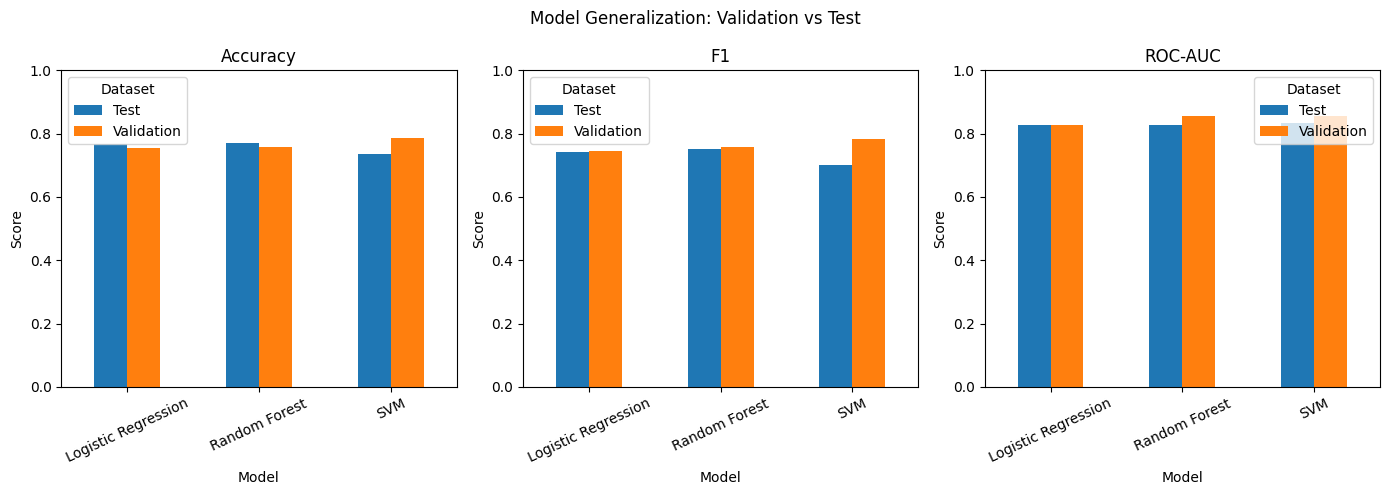

Saved comparison table and SVG/PNG figures.
Test rows: 299
Test feature rows: 299


In [65]:

# STEP 24: Validation vs test performance comparison

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)
from IPython.display import display as show_output

RESULT_DIR = "/content/drive/MyDrive/PRG4206_Arrhythmia_Project/results"

# Validation results using the same fitted tuned models
y_val_array = np.asarray(y_val).astype(int)
comparison_rows = []

for name, model in tuned_models.items():
    val_pred = model.predict(X_val)
    val_prob = model.predict_proba(X_val)[:, 1]

    test_pred = test_predictions[name]
    test_prob = test_probabilities[name]

    for split_name, yt, yp, prob in [
        ("Validation", y_val_array, val_pred, val_prob),
        ("Test", y_test_array, test_pred, test_prob)
    ]:
        comparison_rows.append({
            "Model": name,
            "Split": split_name,
            "N": len(yt),
            "Accuracy": accuracy_score(yt, yp),
            "Precision": precision_score(yt, yp, zero_division=0),
            "Sensitivity": recall_score(yt, yp, zero_division=0),
            "F1": f1_score(yt, yp, zero_division=0),
            "ROC-AUC": roc_auc_score(yt, prob)
        })

comparison_df = pd.DataFrame(comparison_rows)

show_output(comparison_df.round(4))

comparison_df.to_csv(
    os.path.join(RESULT_DIR, "validation_vs_test_comparison.csv"),
    index=False
)

# Plot validation and test scores side by side
metrics = ["Accuracy", "F1", "ROC-AUC"]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, metric in zip(axes, metrics):
    pivot = comparison_df.pivot(
        index="Model", columns="Split", values=metric
    )
    pivot.plot(kind="bar", ax=ax, rot=25)
    ax.set_title(metric)
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.legend(title="Dataset")

fig.suptitle("Model Generalization: Validation vs Test")
fig.tight_layout()

for ext in ["png", "svg"]:
    fig.savefig(
        os.path.join(RESULT_DIR, f"validation_vs_test.{ext}"),
        bbox_inches="tight"
    )

plt.show()

print("Saved comparison table and SVG/PNG figures.")
print("Test rows:", len(y_test_array))
print("Test feature rows:", len(X_test))


**Build an interactive ECG classification prototype in Colab**

In [66]:

# STEP 25: Interactive ECG classification demo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets

from IPython.display import display, clear_output

# Choose the model for the demo.
# Random Forest had the strongest overall test-set F1 and sensitivity.
demo_model_name = "Random Forest"
demo_model = tuned_models[demo_model_name]

# Use test records only for demonstrating the already-trained model
demo_features = X_test.reset_index(drop=True)
demo_labels = np.asarray(y_test).astype(int)

# Use IDs if the test dataframe is available
if "test_df" in globals() and "ecg_id" in test_df.columns:
    demo_ids = test_df["ecg_id"].reset_index(drop=True)
else:
    demo_ids = pd.Series(
        [f"Test record {i}" for i in range(len(demo_features))]
    )

record_selector = widgets.IntSlider(
    value=0,
    min=0,
    max=len(demo_features) - 1,
    step=1,
    description="Record:",
    continuous_update=False,
    style={"description_width": "initial"},
    layout=widgets.Layout(width="500px")
)

output = widgets.Output()

def show_prediction(record_position):
    with output:
        clear_output(wait=True)

        record = demo_features.iloc[[record_position]]
        actual = int(demo_labels[record_position])

        predicted = int(demo_model.predict(record)[0])
        probability = float(demo_model.predict_proba(record)[0, 1])

        print("ECG CLASSIFICATION DEMO")
        print("=" * 35)
        print(f"Model: {demo_model_name}")
        print(f"ECG ID: {demo_ids.iloc[record_position]}")
        print(f"Predicted class: {'ABNORMAL' if predicted == 1 else 'NORMAL'}")
        print(f"Probability of abnormal: {probability:.1%}")
        print(f"Actual dataset label: {'ABNORMAL' if actual == 1 else 'NORMAL'}")
        print(f"Prediction: {'Correct' if predicted == actual else 'Incorrect'}")

        # Visualize the model's probability for this record
        fig, ax = plt.subplots(figsize=(6, 1.8))
        ax.barh(["Abnormal probability"], [probability])
        ax.set_xlim(0, 1)
        ax.axvline(0.5, linestyle="--")
        ax.set_xlabel("Probability")
        ax.set_title("Model output (threshold = 0.50)")
        plt.tight_layout()
        plt.show()

        print(
            "\nResearch prototype only. This model is not validated "
            "for clinical diagnosis or treatment decisions."
        )

def on_record_change(change):
    if change["name"] == "value":
        show_prediction(change["new"])

record_selector.observe(on_record_change, names="value")

display(record_selector, output)
show_prediction(record_selector.value)


IntSlider(value=0, continuous_update=False, description='Record:', layout=Layout(width='500px'), max=298, styl…

Output()

**Adding explainability to the ECG demo**

**How to read the plot**

 Positive SHAP values push the prediction toward Abnormal.

 Negative SHAP values push it toward Normal.

 Larger absolute values indicate greater influence on this specific prediction.

This explains the model’s behaviour, not the medical cause of an ECG abnormality.

Calculating SHAP explanation for one record...


  0%|          | 0/1 [00:00<?, ?it/s]

,Feature,SHAP value,Absolute SHAP
18,III_min,0.05185,0.05185
38,AVL_energy,0.03193,0.03193
42,AVF_min,0.02957,0.02957
81,V5_std,0.02548,0.02548
35,AVL_max,0.02467,0.02467
37,AVL_rms,0.01912,0.01912
2,I_min,0.01596,0.01596
77,V4_rms,0.01277,0.01277
47,AVF_range,0.01242,0.01242
57,V2_std,0.01098,0.01098


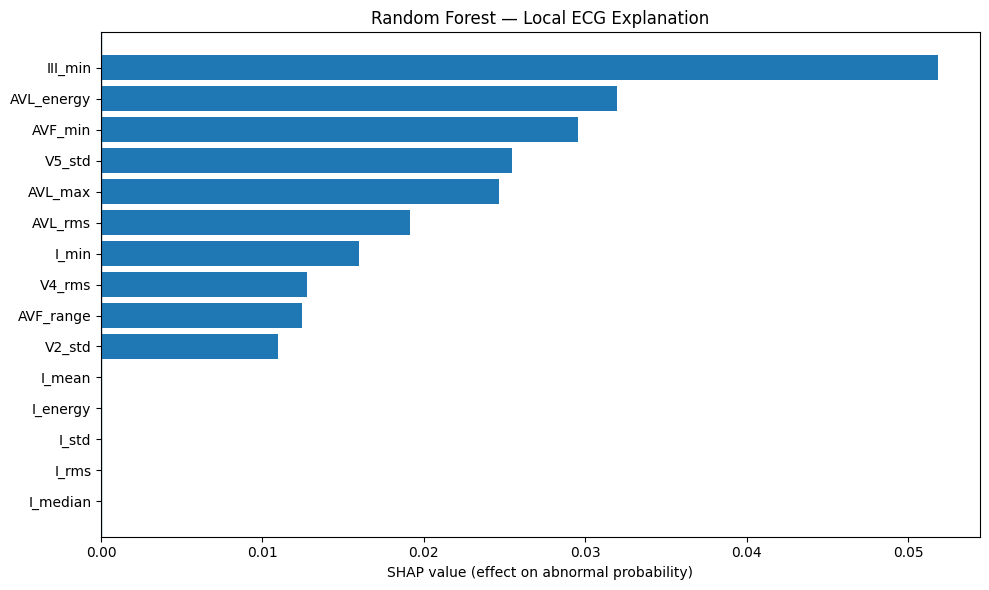

Saved local explanation to: /content/drive/MyDrive/PRG4206_Arrhythmia_Project/results


In [67]:

# STEP 26: Explain Random Forest predictions with SHAP

!pip -q install shap

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import ipywidgets as widgets

from IPython.display import display, clear_output

RESULT_DIR = "/content/drive/MyDrive/PRG4206_Arrhythmia_Project/results"
os.makedirs(RESULT_DIR, exist_ok=True)

# Use the same model as the interactive demo
explain_model = tuned_models["Random Forest"]
feature_names = list(X_train.columns)

# A small training-only background dataset
background = shap.sample(X_train, min(20, len(X_train)), random_state=42)

# Explain probability of the abnormal class
def abnormal_probability_rf(data):
    data_df = pd.DataFrame(data, columns=feature_names)
    return explain_model.predict_proba(data_df)[:, 1]

explainer_rf = shap.KernelExplainer(
    abnormal_probability_rf,
    background
)

# Pick one test record for a demonstration explanation
# Do not use this explanation to tune or select the model.
record_position = 0
record = X_test.iloc[[record_position]]

print("Calculating SHAP explanation for one record...")
sv = explainer_rf.shap_values(record, nsamples=100)
sv = np.asarray(sv)

if sv.ndim == 3:
    sv = sv[0, :, 0]

sv = sv.reshape(-1)

local_importance = pd.DataFrame({
    "Feature": feature_names,
    "SHAP value": sv
})
local_importance["Absolute SHAP"] = local_importance["SHAP value"].abs()
local_importance = local_importance.sort_values(
    "Absolute SHAP", ascending=False
)

display(local_importance.head(15).round(5))

# Plot top 15 features
plot_df = local_importance.head(15).sort_values("SHAP value")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_df["Feature"], plot_df["SHAP value"])
ax.axvline(0, linewidth=1)
ax.set_xlabel("SHAP value (effect on abnormal probability)")
ax.set_title("Random Forest — Local ECG Explanation")
fig.tight_layout()

for ext in ["png", "svg"]:
    fig.savefig(
        os.path.join(RESULT_DIR, f"random_forest_local_shap.{ext}"),
        bbox_inches="tight"
    )

plt.show()

local_importance.to_csv(
    os.path.join(RESULT_DIR, "random_forest_local_shap.csv"),
    index=False
)

print("Saved local explanation to:", RESULT_DIR)


**Audit existing Colab project**

In [68]:

# STEP 1: Audit existing project files

import os
import pandas as pd
from pathlib import Path
from IPython.display import display as show_output

PROJECT_DIR = Path(
    "/content/drive/MyDrive/PRG4206_Arrhythmia_Project"
)

if not PROJECT_DIR.exists():
    raise FileNotFoundError(
        "Project folder not found. Mount Google Drive and verify PROJECT_DIR."
    )

print("PROJECT DIRECTORY:", PROJECT_DIR)

# Inspect the project folders
for folder in ["data", "processed", "models", "results"]:
    path = PROJECT_DIR / folder
    print(f"\n{folder.upper()}: {'FOUND' if path.exists() else 'NOT FOUND'}")

    if path.exists():
        files = sorted(
            p for p in path.iterdir()
            if p.is_file()
        )
        if files:
            for file in files:
                print(f"  {file.name} ({file.stat().st_size:,} bytes)")
        else:
            print("  No files directly inside this folder.")

# Inspect processed feature CSV
feature_path = (
    PROJECT_DIR / "processed" /
    "ptbxl_3000_subset_features.csv"
)

if feature_path.exists():
    features_audit = pd.read_csv(feature_path)

    print("\nFEATURE DATASET SUMMARY")
    print("Shape:", features_audit.shape)
    print("Missing values:", int(features_audit.isna().sum().sum()))

    if "target" in features_audit.columns:
        print("\nClass counts (0 = Normal, 1 = Abnormal):")
        show_output(
            features_audit["target"]
            .value_counts()
            .sort_index()
            .rename_axis("target")
            .to_frame("records")
        )

    if "strat_fold" in features_audit.columns:
        print("\nRecord counts by official fold:")
        show_output(
            features_audit.groupby("strat_fold")
            .size()
            .rename("records")
            .to_frame()
        )
else:
    print("\nProcessed feature CSV not found.")

# Check saved models and important outputs
expected_files = [
    "models/logistic_regression_tuned.joblib",
    "models/random_forest_tuned.joblib",
    "models/svm_tuned.joblib",
    "results/final_test_results.csv",
    "results/validation_vs_test_comparison.csv",
    "results/svm_permutation_importance_top15.svg",
    "results/shap_correct_normal.svg",
    "results/shap_correct_abnormal.svg",
    "results/shap_misclassified.svg",
]

print("\nEXPECTED OUTPUT AUDIT")
audit_rows = []

for relative_path in expected_files:
    path = PROJECT_DIR / relative_path
    audit_rows.append({
        "File": relative_path,
        "Status": "FOUND" if path.is_file() else "MISSING",
        "Size (bytes)": path.stat().st_size if path.is_file() else None
    })

show_output(pd.DataFrame(audit_rows))

print("\nAudit complete. No models were retrained or files overwritten.")


PROJECT DIRECTORY: /content/drive/MyDrive/PRG4206_Arrhythmia_Project

DATA: FOUND
  No files directly inside this folder.

PROCESSED: FOUND
  best_hyperparameters.json (294 bytes)
  hyperparameter_tuning_summary.csv (371 bytes)
  ptbxl_100hz_features.csv (121,262 bytes)
  ptbxl_3000_subset_features.csv (3,800,900 bytes)

MODELS: FOUND
  logistic_regression_tuned.joblib (5,665 bytes)
  random_forest_tuned.joblib (7,869,737 bytes)
  svm_tuned.joblib (1,074,973 bytes)

RESULTS: FOUND
  experiment_metadata.json (758 bytes)
  final_test_confusion_matrices.png (27,546 bytes)
  final_test_confusion_matrices.svg (46,543 bytes)
  final_test_metric_comparison.png (27,968 bytes)
  final_test_metric_comparison.svg (37,117 bytes)
  final_test_precision_recall.png (42,841 bytes)
  final_test_precision_recall.svg (40,401 bytes)
  final_test_results.csv (479 bytes)
  final_test_roc_curves.png (46,422 bytes)
  final_test_roc_curves.svg (44,092 bytes)
  random_forest_local_shap.csv (1,933 bytes)
  rando

,records
target,
0,1499
1,1498



Record counts by official fold:


,records
strat_fold,
1,300
2,300
3,300
4,299
5,300
6,300
7,299
8,300
9,300



EXPECTED OUTPUT AUDIT


,File,Status,Size (bytes)
0,models/logistic_regression_tuned.joblib,FOUND,5665
1,models/random_forest_tuned.joblib,FOUND,7869737
2,models/svm_tuned.joblib,FOUND,1074973
3,results/final_test_results.csv,FOUND,479
4,results/validation_vs_test_comparison.csv,FOUND,745
5,results/svm_permutation_importance_top15.svg,FOUND,52541
6,results/shap_correct_normal.svg,FOUND,47846
7,results/shap_correct_abnormal.svg,FOUND,46197
8,results/shap_misclassified.svg,FOUND,47540



Audit complete. No models were retrained or files overwritten.


Results: verified
- Feature dataset: 2,997 records × 100 columns, with zero missing values.
- Class balance: 1,499 normal and 1,498 abnormal records.
- Models: all three tuned model files exist.
- Evaluation: final test results, validation comparison, confusion matrices, ROC curves and precision–recall curves exist.
- Explainability: global SVM permutation importance and three local SVM SHAP explanations exist; a Random Forest local SHAP output also exists.
- Architecture diagram: not yet present in the audited results folder.

**Verify data integrity and split counts**

In [69]:

# STEP 2: Final data-integrity checks

import pandas as pd
from pathlib import Path
from IPython.display import display as show_output

PROJECT_DIR = Path(
    "/content/drive/MyDrive/PRG4206_Arrhythmia_Project"
)
FEATURE_PATH = PROJECT_DIR / "processed" / "ptbxl_3000_subset_features.csv"

df = pd.read_csv(FEATURE_PATH)

# Class distribution by official fold
print("1. CLASS DISTRIBUTION BY FOLD")
fold_counts = pd.crosstab(
    df["strat_fold"],
    df["target"]
).reindex(columns=[0, 1], fill_value=0)

fold_counts.columns = ["Normal (0)", "Abnormal (1)"]
fold_counts["Total"] = fold_counts.sum(axis=1)
show_output(fold_counts)

# Official split sizes
print("\n2. OFFICIAL SPLIT SIZES")
split_summary = pd.DataFrame([
    {
        "Split": "Train (folds 1–8)",
        "Records": int(df["strat_fold"].between(1, 8).sum())
    },
    {
        "Split": "Validation (fold 9)",
        "Records": int((df["strat_fold"] == 9).sum())
    },
    {
        "Split": "Test (fold 10)",
        "Records": int((df["strat_fold"] == 10).sum())
    }
])
show_output(split_summary)

# Duplicate ECG IDs
print("\n3. DUPLICATE CHECK")
print("Duplicate ECG IDs:",
      int(df["ecg_id"].duplicated().sum()))
print("Duplicate full rows:",
      int(df.duplicated().sum()))

# Patient overlap across splits
print("\n4. PATIENT OVERLAP CHECK")
train_patients = set(
    df.loc[df["strat_fold"].between(1, 8), "patient_id"].dropna()
)
val_patients = set(
    df.loc[df["strat_fold"] == 9, "patient_id"].dropna()
)
test_patients = set(
    df.loc[df["strat_fold"] == 10, "patient_id"].dropna()
)

overlap_summary = pd.DataFrame([
    {"Comparison": "Train vs validation",
     "Overlapping patients": len(train_patients & val_patients)},
    {"Comparison": "Train vs test",
     "Overlapping patients": len(train_patients & test_patients)},
    {"Comparison": "Validation vs test",
     "Overlapping patients": len(val_patients & test_patients)}
])
show_output(overlap_summary)

# Basic integrity assertions
print("\n5. FINAL CHECKS")
print("Rows:", len(df))
print("Missing values:", int(df.isna().sum().sum()))
print("Target labels:", sorted(df["target"].dropna().unique().tolist()))
print("Fold values:", sorted(df["strat_fold"].dropna().unique().tolist()))

assert df["target"].isin([0, 1]).all(), "Unexpected target labels found."
assert df["ecg_id"].is_unique, "Duplicate ECG IDs detected."
assert df["strat_fold"].between(1, 10).all(), "Unexpected fold values."

print("\nBasic integrity checks passed.")
print("Review the patient-overlap table and class counts above.")


1. CLASS DISTRIBUTION BY FOLD


,Normal (0),Abnormal (1),Total
strat_fold,,,
1,150,150,300
2,150,150,300
3,150,150,300
4,149,150,299
5,150,150,300
6,150,150,300
7,150,149,299
8,150,150,300
9,150,150,300



2. OFFICIAL SPLIT SIZES


,Split,Records
0,Train (folds 1–8),2398
1,Validation (fold 9),300
2,Test (fold 10),299



3. DUPLICATE CHECK
Duplicate ECG IDs: 0
Duplicate full rows: 0

4. PATIENT OVERLAP CHECK


,Comparison,Overlapping patients
0,Train vs validation,0
1,Train vs test,0
2,Validation vs test,0



5. FINAL CHECKS
Rows: 2997
Missing values: 0
Target labels: [0, 1]
Fold values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Basic integrity checks passed.
Review the patient-overlap table and class counts above.


Train: 2,398 ECGs



Validation: 300 ECGs



Test: 299 ECGs



Duplicate ECG IDs: 0



Missing feature values: 0



Patient overlap across splits: 0

Architecture diagram regenerated successfully.
SVG: /content/drive/MyDrive/PRG4206_Arrhythmia_Project/results/ptbxl_system_architecture.svg (19,091 bytes)
PNG: /content/drive/MyDrive/PRG4206_Arrhythmia_Project/results/ptbxl_system_architecture.png (167,551 bytes)


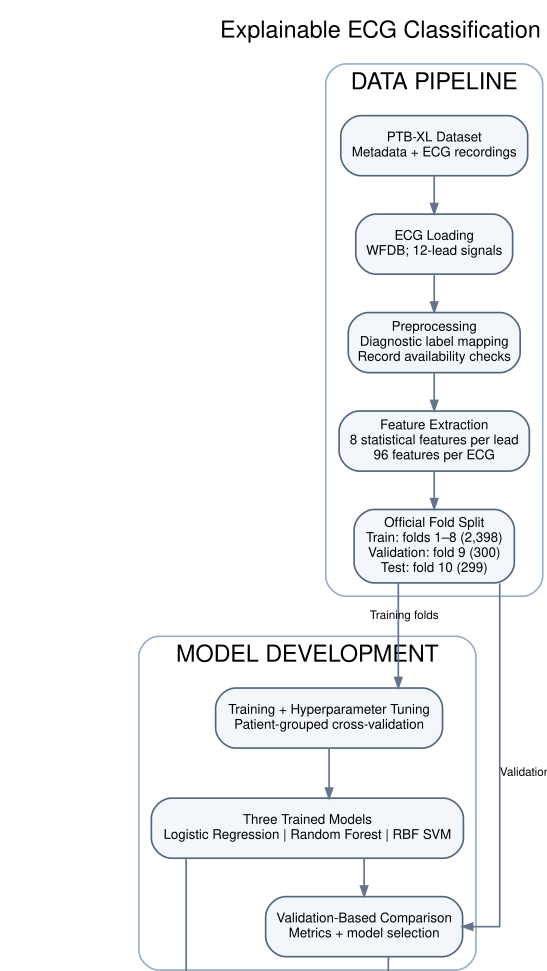

In [73]:
!pip -q install graphviz

import os
from graphviz import Digraph
from IPython.display import display

RESULT_DIR = "/content/drive/MyDrive/PRG4206_Arrhythmia_Project/results"
os.makedirs(RESULT_DIR, exist_ok=True)

dot = Digraph("PTBXL_ECG_System_Architecture", format="svg")

# Compact overall layout
dot.attr(
    rankdir="TB",
    label="Explainable ECG Classification Using PTB-XL",
    labelloc="t",
    fontsize="14",
    fontname="Helvetica",
    nodesep="0.20",
    ranksep="0.30",
    splines="ortho",
    pad="0.10",
    dpi="120"
)

dot.attr(
    "node",
    shape="box",
    style="rounded,filled",
    fontname="Helvetica",
    fontsize="8",
    margin="0.08,0.05",
    color="#52677D",
    fillcolor="#F3F6FA"
)

dot.attr(
    "edge",
    color="#64748B",
    arrowsize="0.6",
    fontname="Helvetica",
    fontsize="7"
)

# 1. Data pipeline
with dot.subgraph(name="cluster_data") as c:
    c.attr(label="DATA PIPELINE", color="#9AAFC4", style="rounded")
    c.node("input", "PTB-XL Dataset\nMetadata + ECG recordings")
    c.node("load", "ECG Loading\nWFDB; 12-lead signals")
    c.node("prep", "Preprocessing\nDiagnostic label mapping\nRecord availability checks")
    c.node("features", "Feature Extraction\n8 statistical features per lead\n96 features per ECG")
    c.node("split", "Official Fold Split\nTrain: folds 1–8 (2,398)\nValidation: fold 9 (300)\nTest: fold 10 (299)")
    c.edges([
        ("input", "load"),
        ("load", "prep"),
        ("prep", "features"),
        ("features", "split")
    ])

# 2. Model development
with dot.subgraph(name="cluster_training") as c:
    c.attr(label="MODEL DEVELOPMENT", color="#9AAFC4", style="rounded")
    c.node("train", "Training + Hyperparameter Tuning\nPatient-grouped cross-validation")
    c.node("models", "Three Trained Models\nLogistic Regression | Random Forest | RBF SVM")
    c.node("selection", "Validation-Based Comparison\nMetrics + model selection")
    c.edge("train", "models")
    c.edge("models", "selection")

# 3. Prediction and analysis
with dot.subgraph(name="cluster_analysis") as c:
    c.attr(label="INFERENCE AND ANALYSIS", color="#9AAFC4", style="rounded")
    c.node("newinput", "Input Feature Vector\n96 engineered features")
    c.node("predict", "Prediction\nNormal / Abnormal\nAbnormal-class probability")
    c.node("evaluate", "Final Test Evaluation\nAccuracy, Precision, Sensitivity,\nSpecificity, F1, ROC-AUC")
    c.node("xai", "Explainability\nPermutation Importance + SHAP")
    c.node("plots", "Evaluation Figures\nConfusion Matrices, ROC, PR Curves")
    c.edges([
        ("newinput", "predict"),
        ("predict", "evaluate"),
        ("predict", "xai"),
        ("evaluate", "plots")
    ])

# 4. Output
with dot.subgraph(name="cluster_output") as c:
    c.attr(label="USER INTERFACE AND OUTPUT", color="#9AAFC4", style="rounded")
    c.node("ui", "Interactive Colab Demo\nSelect a feature-based test record")
    c.node("output", "Output\nPredicted Class + Probability\nExplanation + Research Disclaimer")
    c.edge("ui", "output")

# Connections between sections
dot.edge("split", "train", label="Training folds")
dot.edge("split", "selection", label="Validation fold")
dot.edge("selection", "newinput", label="Selected model")
dot.edge("models", "evaluate", label="Held-out test fold")
dot.edge("predict", "ui", label="Prediction")
dot.edge("xai", "output", label="Feature contributions")
dot.edge("plots", "output", label="Report figures")

# Save both formats
base_path = os.path.join(RESULT_DIR, "ptbxl_system_architecture")

svg_path = dot.render(
    filename=base_path,
    format="svg",
    cleanup=True
)

png_path = dot.render(
    filename=base_path,
    format="png",
    cleanup=True
)

print("Architecture diagram regenerated successfully.")
print(f"SVG: {svg_path} ({os.path.getsize(svg_path):,} bytes)")
print(f"PNG: {png_path} ({os.path.getsize(png_path):,} bytes)")

display(dot)

**README and requirements file**

In [74]:
import os

PROJECT_DIR = "/content/drive/MyDrive/PRG4206_Arrhythmia_Project"
os.makedirs(PROJECT_DIR, exist_ok=True)

# 1. Create README.md
readme = r"""
# Explainable Machine Learning for ECG Classification Using PTB-XL

## 1. Project Overview
This project investigates binary ECG classification using engineered statistical
features extracted from the PTB-XL dataset. It compares Logistic Regression,
Random Forest, and Support Vector Machine (RBF kernel) models and applies
explainability methods to interpret model predictions.

## 2. Dataset
- Dataset: PTB-XL
- Source: https://physionet.org/content/ptb-xl/1.0.3/
- ECG recordings: 12-lead signals
- Project subset: 2,997 successfully processed records
- Features: 96 statistical features per ECG
- Target: Normal (0) or Abnormal (1)

The project uses a binary label mapping derived from diagnostic statements.
PTB-XL is inherently multi-label, so this transformation simplifies the
original diagnostic information and may hide distinctions between conditions.

The dataset is not included in this project package. Obtain it from PhysioNet
and follow the dataset's access and licensing terms.

## 3. Data Split
The subset uses the official PTB-XL folds:
- Training: folds 1-8 (2,398 records)
- Validation: fold 9 (300 records)
- Test: fold 10 (299 records)

Patient overlap between these splits was checked and none was found.

## 4. Feature Engineering
Eight statistical features were extracted for each of the 12 ECG leads:
- Mean
- Standard deviation
- Minimum
- Maximum
- Median
- Root mean square (RMS)
- Mean-square energy
- Peak-to-peak range

Total: 96 features per ECG.

## 5. Machine Learning Models
Three models were trained and tuned:
1. Logistic Regression
2. Random Forest
3. Support Vector Machine with an RBF kernel

Hyperparameter selection used ROC-AUC and patient-grouped cross-validation.
The final model choice should follow validation results, not test performance.

## 6. Explainability
- Permutation feature importance for the selected SVM model
- SHAP explanations for selected individual predictions
- Error analysis using validation predictions

These methods explain model behavior, not clinical causation. Correlated
engineered features can affect the attribution of importance.

## 7. Test Results
Results on the held-out test set:

| Model | Accuracy | Precision | Sensitivity | Specificity | F1 | ROC-AUC |
|---|---:|---:|---:|---:|---:|---:|
| SVM | 0.7358 | 0.8070 | 0.6174 | 0.8533 | 0.6996 | 0.8343 |
| Random Forest | 0.7692 | 0.8077 | 0.7047 | 0.8333 | 0.7527 | 0.8285 |
| Logistic Regression | 0.7659 | 0.8264 | 0.6711 | 0.8600 | 0.7407 | 0.8274 |

These are experimental results on the project subset, not evidence of clinical
readiness or performance on an external population.

## 8. Project Structure
- `processed/`: engineered feature datasets and tuning summaries
- `models/`: saved trained model artifacts
- `results/`: evaluation results, figures, explainability outputs and metadata
- `data/`: reserved for source data if stored locally

## 9. Running the Project
The project was developed in Google Colab. Mount Google Drive, install the
required dependencies, and run the notebook cells in order.

The saved models expect the same 96 engineered features in the same column
order used during training. The current demonstration uses pre-extracted
features; it does not directly accept raw ECG files.

## 10. Limitations and Ethics
- The subset is much smaller than the full PTB-XL dataset.
- Binary labels collapse multiple diagnostic categories into one class.
- Statistical features discard ECG waveform shape and temporal details.
- Results require further validation on independent clinical data.
- This prototype is for educational research and must not be used to diagnose
  or guide treatment for real patients.
- Handle health-related data responsibly and follow applicable data-use terms.

## 11. Citation
Wagner, P. et al. (2020). PTB-XL, a large publicly available
electrocardiography dataset. Scientific Data, 7, 154.
https://doi.org/10.1038/s41597-020-0495-6

Add the remaining scholarly references required by the coursework report.
"""

with open(os.path.join(PROJECT_DIR, "README.md"), "w", encoding="utf-8") as f:
    f.write(readme.strip() + "\n")

# 2. Create requirements.txt
requirements = """numpy
pandas
scipy
scikit-learn
matplotlib
seaborn
joblib
wfdb
shap
graphviz
ipywidgets
"""

with open(os.path.join(PROJECT_DIR, "requirements.txt"), "w", encoding="utf-8") as f:
    f.write(requirements)

# 3. Verify
for filename in ["README.md", "requirements.txt"]:
    path = os.path.join(PROJECT_DIR, filename)
    print(f"{filename}: {'CREATED' if os.path.exists(path) else 'FAILED'}")
    print(f"Size: {os.path.getsize(path):,} bytes")

print("\nProject documentation files are ready.")

README.md: CREATED
Size: 3,997 bytes
requirements.txt: CREATED
Size: 88 bytes

Project documentation files are ready.


In [75]:
import os
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

PROJECT_DIR = "/content/drive/MyDrive/PRG4206_Arrhythmia_Project"
RESULT_DIR = os.path.join(PROJECT_DIR, "results")
os.makedirs(RESULT_DIR, exist_ok=True)

model_names = ["Logistic Regression", "Random Forest", "SVM"]
rows = []

for split_name, X, y in [
    ("Validation", X_val, y_val),
    ("Test", X_test, y_test)
]:
    for name in model_names:
        model = tuned_models[name]
        y_pred = model.predict(X)
        y_prob = model.predict_proba(X)[:, 1]

        rows.append({
            "Split": split_name,
            "Model": name,
            "Accuracy": accuracy_score(y, y_pred),
            "Macro_Precision": precision_score(
                y, y_pred, average="macro", zero_division=0
            ),
            "Weighted_Precision": precision_score(
                y, y_pred, average="weighted", zero_division=0
            ),
            "Macro_Recall": recall_score(
                y, y_pred, average="macro", zero_division=0
            ),
            "Weighted_Recall": recall_score(
                y, y_pred, average="weighted", zero_division=0
            ),
            "Macro_F1": f1_score(
                y, y_pred, average="macro", zero_division=0
            ),
            "Weighted_F1": f1_score(
                y, y_pred, average="weighted", zero_division=0
            ),
            "ROC_AUC": roc_auc_score(y, y_prob)
        })

metrics_df = pd.DataFrame(rows)

output_path = os.path.join(
    RESULT_DIR, "macro_weighted_metrics.csv"
)
metrics_df.to_csv(output_path, index=False)

display(
    metrics_df.style.format({
        col: "{:.4f}"
        for col in metrics_df.select_dtypes(include="number").columns
    })
)

print(f"\nSaved results to: {output_path}")

,Split,Model,Accuracy,Macro_Precision,Weighted_Precision,Macro_Recall,Weighted_Recall,Macro_F1,Weighted_F1,ROC_AUC
0,Validation,Logistic Regression,0.7533,0.7545,0.7545,0.7533,0.7533,0.7531,0.7531,0.8271
1,Validation,Random Forest,0.7567,0.7567,0.7567,0.7567,0.7567,0.7567,0.7567,0.8561
2,Validation,SVM,0.7867,0.7871,0.7871,0.7867,0.7867,0.7866,0.7866,0.8552
3,Test,Logistic Regression,0.7659,0.7756,0.7754,0.7656,0.7659,0.7637,0.7637,0.8274
4,Test,Random Forest,0.7692,0.7737,0.7736,0.7690,0.7692,0.7682,0.7682,0.8285
5,Test,SVM,0.7358,0.7495,0.7493,0.7354,0.7358,0.7319,0.7320,0.8343



Saved results to: /content/drive/MyDrive/PRG4206_Arrhythmia_Project/results/macro_weighted_metrics.csv


In [76]:
import os
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

PROJECT_DIR = "/content/drive/MyDrive/PRG4206_Arrhythmia_Project"
RESULT_DIR = os.path.join(PROJECT_DIR, "results")
os.makedirs(RESULT_DIR, exist_ok=True)

# Use the existing split variables
baseline_models = {
    "Dummy - Majority": DummyClassifier(strategy="most_frequent"),
    "Dummy - Stratified": DummyClassifier(
        strategy="stratified", random_state=42
    )
}

baseline_rows = []

for name, model in baseline_models.items():
    model.fit(X_train, y_train)

    for split_name, X, y in [
        ("Validation", X_val, y_val),
        ("Test", X_test, y_test)
    ]:
        pred = model.predict(X)
        prob = model.predict_proba(X)[:, 1]

        baseline_rows.append({
            "Split": split_name,
            "Model": name,
            "Accuracy": accuracy_score(y, pred),
            "Macro_Precision": precision_score(
                y, pred, average="macro", zero_division=0
            ),
            "Weighted_Precision": precision_score(
                y, pred, average="weighted", zero_division=0
            ),
            "Macro_Recall": recall_score(
                y, pred, average="macro", zero_division=0
            ),
            "Weighted_Recall": recall_score(
                y, pred, average="weighted", zero_division=0
            ),
            "Macro_F1": f1_score(
                y, pred, average="macro", zero_division=0
            ),
            "Weighted_F1": f1_score(
                y, pred, average="weighted", zero_division=0
            ),
            "ROC_AUC": (
                roc_auc_score(y, prob)
                if len(set(y)) == 2 else float("nan")
            )
        })

baseline_df = pd.DataFrame(baseline_rows)

# Save baseline results
baseline_path = os.path.join(RESULT_DIR, "baseline_results.csv")
baseline_df.to_csv(baseline_path, index=False)

print("BASELINE RESULTS")
display(baseline_df.round(4))

print(f"\nSaved to: {baseline_path}")

BASELINE RESULTS


,Split,Model,Accuracy,Macro_Precision,Weighted_Precision,Macro_Recall,Weighted_Recall,Macro_F1,Weighted_F1,ROC_AUC
0,Validation,Dummy - Majority,0.5000,0.2500,0.2500,0.5000,0.5000,0.3333,0.3333,0.5000
1,Test,Dummy - Majority,0.5017,0.2508,0.2517,0.5000,0.5017,0.3341,0.3352,0.5000
2,Validation,Dummy - Stratified,0.5000,0.5000,0.5000,0.5000,0.5000,0.4998,0.4998,0.5000
3,Test,Dummy - Stratified,0.4849,0.4848,0.4849,0.4849,0.4849,0.4847,0.4847,0.4849



Saved to: /content/drive/MyDrive/PRG4206_Arrhythmia_Project/results/baseline_results.csv


In [78]:
import os
import pandas as pd

PROJECT_DIR = "/content/drive/MyDrive/PRG4206_Arrhythmia_Project"
RESULT_DIR = os.path.join(PROJECT_DIR, "results")

baseline_path = os.path.join(RESULT_DIR, "baseline_results.csv")
metrics_path = os.path.join(RESULT_DIR, "macro_weighted_metrics.csv")

baseline_df = pd.read_csv(baseline_path)
models_df = pd.read_csv(metrics_path)

comparison_df = pd.concat(
    [baseline_df, models_df],
    ignore_index=True
)

comparison_df = comparison_df.sort_values(
    ["Split", "Model"]
).reset_index(drop=True)

output_path = os.path.join(
    RESULT_DIR, "complete_model_comparison.csv"
)
comparison_df.to_csv(output_path, index=False)

display(comparison_df.round(4))

print(f"\nSaved complete comparison to: {output_path}")

,Split,Model,Accuracy,Macro_Precision,Weighted_Precision,Macro_Recall,Weighted_Recall,Macro_F1,Weighted_F1,ROC_AUC
0,Test,Dummy - Majority,0.5017,0.2508,0.2517,0.5000,0.5017,0.3341,0.3352,0.5000
1,Test,Dummy - Stratified,0.4849,0.4848,0.4849,0.4849,0.4849,0.4847,0.4847,0.4849
2,Test,Logistic Regression,0.7659,0.7756,0.7754,0.7656,0.7659,0.7637,0.7637,0.8274
3,Test,Random Forest,0.7692,0.7737,0.7736,0.7690,0.7692,0.7682,0.7682,0.8285
4,Test,SVM,0.7358,0.7495,0.7493,0.7354,0.7358,0.7319,0.7320,0.8343
5,Validation,Dummy - Majority,0.5000,0.2500,0.2500,0.5000,0.5000,0.3333,0.3333,0.5000
6,Validation,Dummy - Stratified,0.5000,0.5000,0.5000,0.5000,0.5000,0.4998,0.4998,0.5000
7,Validation,Logistic Regression,0.7533,0.7545,0.7545,0.7533,0.7533,0.7531,0.7531,0.8271
8,Validation,Random Forest,0.7567,0.7567,0.7567,0.7567,0.7567,0.7567,0.7567,0.8561
9,Validation,SVM,0.7867,0.7871,0.7871,0.7867,0.7867,0.7866,0.7866,0.8552



Saved complete comparison to: /content/drive/MyDrive/PRG4206_Arrhythmia_Project/results/complete_model_comparison.csv


In [79]:
import os
import json
import platform
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import sklearn
import scipy
import joblib

PROJECT_DIR = "/content/drive/MyDrive/PRG4206_Arrhythmia_Project"
RESULT_DIR = os.path.join(PROJECT_DIR, "results")
os.makedirs(RESULT_DIR, exist_ok=True)

metadata = {
    "project": "Explainable Machine Learning for ECG Classification Using PTB-XL",
    "experiment_version": "1.0",
    "recorded_at_utc": datetime.now(timezone.utc).isoformat(),
    "random_seed": 42,
    "dataset": "PTB-XL",
    "dataset_subset_records": 2997,
    "engineered_features": 96,
    "target_labels": {
        "0": "Normal",
        "1": "Abnormal"
    },
    "split": {
        "training_folds": "1-8",
        "training_records": 2398,
        "validation_fold": 9,
        "validation_records": 300,
        "test_fold": 10,
        "test_records": 299
    },
    "models": {
        "Logistic Regression": {
            "best_parameters": {
                "classifier__C": 100,
                "classifier__solver": "lbfgs"
            }
        },
        "Random Forest": {
            "best_parameters": {
                "n_estimators": 200,
                "min_samples_leaf": 2,
                "max_features": "sqrt",
                "max_depth": 20
            }
        },
        "SVM": {
            "best_parameters": {
                "classifier__C": 10,
                "classifier__gamma": "scale",
                "classifier__kernel": "rbf"
            }
        }
    },
    "software_versions": {
        "python": platform.python_version(),
        "scikit_learn": sklearn.__version__,
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scipy": scipy.__version__,
        "joblib": joblib.__version__
    },
    "selection_rule": (
        "Choose the final candidate using validation results; "
        "do not select a model based on test performance."
    ),
    "baseline_results_file": "baseline_results.csv",
    "comparison_results_file": "complete_model_comparison.csv",
    "macro_weighted_metrics_file": "macro_weighted_metrics.csv"
}

output_path = os.path.join(RESULT_DIR, "experiment_metadata.json")

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Experiment metadata saved:")
print(output_path)
print("\nSoftware versions:")
for name, version in metadata["software_versions"].items():
    print(f"{name}: {version}")

print("\nModel configurations:")
for name, details in metadata["models"].items():
    print(f"{name}: {details['best_parameters']}")

Experiment metadata saved:
/content/drive/MyDrive/PRG4206_Arrhythmia_Project/results/experiment_metadata.json

Software versions:
python: 3.13.16
scikit_learn: 1.6.1
numpy: 2.1.3
pandas: 2.2.3
scipy: 1.16.3
joblib: 1.6.0

Model configurations:
Logistic Regression: {'classifier__C': 100, 'classifier__solver': 'lbfgs'}
Random Forest: {'n_estimators': 200, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20}
SVM: {'classifier__C': 10, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
